**Author: Dhrubajyoti Ghosh**

**Capstone Project 2: Credit Card Fraud Detection**

Version: 1.0

Date: 15 Sep 2026

--------------------------------------------

ML & DL Model for Credit Card Fraud Detection
----------------------------

**GitHub Link**

https://github.com/Dhruba041/ML_DL_12_Credit_Card_Fraud_Detector

**Streamlit Link**

https://mldl12creditcardfrauddetector-d6b82r7fxtyfazobjk7ye6.streamlit.app/

**Note:** MDD file is saved in GitHub Link


---------------------

In [1]:
#importing libraries

import pandas as pd
import numpy as np
import pickle


#For Google Collab

from google.colab import drive
import re
import gdown # Import gdown for downloading from Google Drive

drive_link = 'https://drive.google.com/file/d/1nx8XeA6y6gzMmyRJAyYvfRSZ15aDcjK9/view?usp=drive_link'
file_id = drive_link.split("/d/")[1].split("/")[0]
download_url = f"https://drive.google.com/uc?id={file_id}"
df_org = pd.read_csv(download_url)

In [2]:
#Importing the dataset into dataframe
df_org = pd.read_csv('creditcard.csv')

In [3]:
#Checking the new dimensions of the dataframe
df_org.shape

(284807, 31)

In [4]:
#Analyze the class distribution (check for class imbalance)
df_org["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [5]:
#checking sample data
df_org

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [6]:
#Crross verifying precision of columns
print(df_org["V1"].iloc[0])
#df = pd.read_csv("creditcard.csv", dtype={"V1": "float64"}) #preserving in case precision is lost during reading csv

#Alternative approach
#from decimal import Decimal
#import pandas as pd

#df = pd.read_csv(
#    "creditcard.csv",
#    converters={"Amount": Decimal}
#)


-1.359807134


In [7]:
#checking information about the dataframe
df_org.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [8]:
#Though not required yet cross-checking for null values. In info() we can already see not null count = total number of rows indicating no null values
df_org.isnull().sum().to_frame(name="null_count").reset_index().rename(columns={"index": "column_name"})

,column_name,null_count
0,Time,0
1,V1,0
2,V2,0
3,V3,0
4,V4,0
5,V5,0
6,V6,0
7,V7,0
8,V8,0
9,V9,0


In [9]:
#Getting a quick statistical summary
df_org.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,0.000017,0.000008,0.014970,0.000023,0.000022,-0.000016,0.000029,0.000003,0.004311,...,-3.405795e-13,-5.723161e-13,-9.725925e-13,1.464150e-12,-6.987098e-13,-5.617860e-13,3.332081e-12,-3.518874e-12,88.349619,0.001727
std,47488.145955,1.958679,1.651295,8.073856,1.415859,1.380234,1.332244,1.237076,1.194354,2.538010,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-0.920327,-0.598532,-0.890365,-0.848611,-0.691568,-0.768290,-0.554011,-0.208630,-0.643068,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,0.018027,0.065467,0.179832,-0.019816,-0.054314,-0.274159,0.040104,0.022358,-0.051331,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315632,0.803724,1.027212,0.743355,0.611926,0.398487,0.570450,0.327349,0.597139,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930,22.057729,4232.000000,16.875344,34.801666,73.301626,120.589494,20.007208,1221.000000,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [10]:
#checking for duplicate rows
int(df_org.duplicated().sum())

1081

In [11]:
#Observing the duplicate rows
df_duplicate = df_org[df_org.duplicated(keep=False)]
df_duplicate

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
32,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
34,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
112,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283485,171627.0,-1.457978,1.378203,0.811515,-0.603760,-0.711883,-0.471672,-0.282535,0.880654,0.052808,...,0.284205,0.949659,-0.216949,0.083250,0.044944,0.639933,0.219432,0.116772,11.93,0
284190,172233.0,-2.667936,3.160505,-3.355984,1.007845,-0.377397,-0.109730,-0.667233,2.309700,-1.639306,...,0.391483,0.266536,-0.079853,-0.096395,0.086719,-0.451128,-1.183743,-0.222200,55.66,0
284191,172233.0,-2.667936,3.160505,-3.355984,1.007845,-0.377397,-0.109730,-0.667233,2.309700,-1.639306,...,0.391483,0.266536,-0.079853,-0.096395,0.086719,-0.451128,-1.183743,-0.222200,55.66,0
284192,172233.0,-2.691642,3.123168,-3.339407,1.017018,-0.293095,-0.167054,-0.745886,2.325616,-1.634651,...,0.402639,0.259746,-0.086606,-0.097597,0.083693,-0.453584,-1.205466,-0.213020,36.74,0


In [12]:
#Observing the duplicate rows
df_duplicate[df_duplicate["Class"] == 1]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
102441,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,...,27.202839,-8.887017,5.303607,-0.639435,0.263203,-0.108877,1.269566,0.939407,1.00,1
102442,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,...,27.202839,-8.887017,5.303607,-0.639435,0.263203,-0.108877,1.269566,0.939407,1.00,1
102443,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,...,27.202839,-8.887017,5.303607,-0.639435,0.263203,-0.108877,1.269566,0.939407,1.00,1
102444,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,...,27.202839,-8.887017,5.303607,-0.639435,0.263203,-0.108877,1.269566,0.939407,1.00,1
102445,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,...,27.202839,-8.887017,5.303607,-0.639435,0.263203,-0.108877,1.269566,0.939407,1.00,1
102446,68207.0,-13.192671,12.785971,-9.906650,3.320337,-4.801176,5.760059,-18.750889,-37.353443,-0.391540,...,27.202839,-8.887017,5.303607,-0.639435,0.263203,-0.108877,1.269566,0.939407,1.00,1
141257,84204.0,-0.937843,3.462889,-6.445104,4.932199,-2.233983,-2.291561,-5.695594,1.338825,-4.322377,...,1.066550,-0.521657,-0.319917,-0.405859,0.906802,1.165784,1.374495,0.729889,0.00,1
141258,84204.0,-0.937843,3.462889,-6.445104,4.932199,-2.233983,-2.291561,-5.695594,1.338825,-4.322377,...,1.066550,-0.521657,-0.319917,-0.405859,0.906802,1.165784,1.374495,0.729889,0.00,1
141259,84204.0,-1.927453,1.827621,-7.019495,5.348303,-2.739188,-2.107219,-5.015848,1.205868,-4.382713,...,1.376938,-0.792017,-0.771414,-0.379574,0.718717,1.111151,1.277707,0.819081,512.25,1
141260,84204.0,-1.927453,1.827621,-7.019495,5.348303,-2.739188,-2.107219,-5.015848,1.205868,-4.382713,...,1.376938,-0.792017,-0.771414,-0.379574,0.718717,1.111151,1.277707,0.819081,512.25,1


In [13]:
#Since Time of duplicate records are also same. Hence, proceeding with removal of duplicate records.
df_org = df_org.drop_duplicates()

In [14]:
#Checking the new dimensions of the dataframe
df_org.shape

(283726, 31)

In [15]:
#Analyze the class distribution (check for class imbalance) after duplicate removal
df_org["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

Since the data contains only numerical input variables which are the result of a PCA transformation, hence renaming of columns is not required.
Also, there are no missing values as seen above. Hence, imputations is also not required.

In [16]:
df_org.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [17]:
#copying original dataframe after EDA to a new dataframe for future use
df = df_org.copy()
df_viz = df_org.copy() #for data visualization

----------------------------------
**Data Visualtization**

----------------------------------

In [18]:
#importing libraries
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

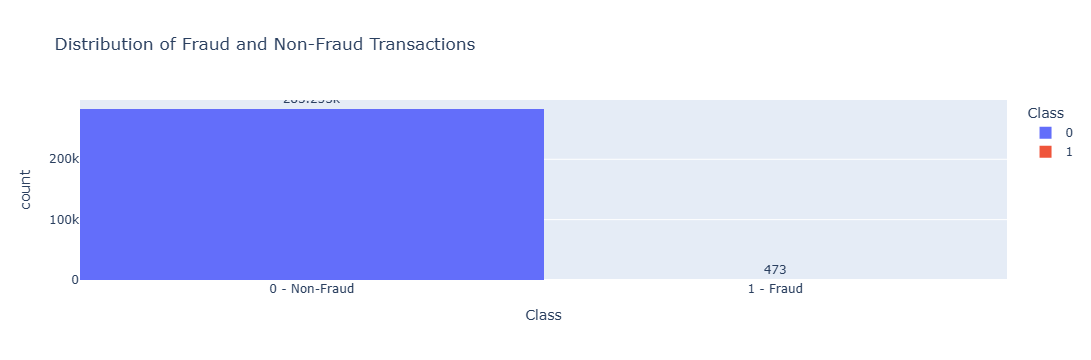

In [19]:
#Class Distribution
fig = px.histogram(
    df_viz,
    x="Class",
    color="Class",
    text_auto=True,
    title="Distribution of Fraud and Non-Fraud Transactions"
)

fig.update_xaxes(
    tickvals=[0, 1],
    ticktext=["0 - Non-Fraud", "1 - Fraud"]
)

fig.update_traces(textposition="outside")
fig.show()

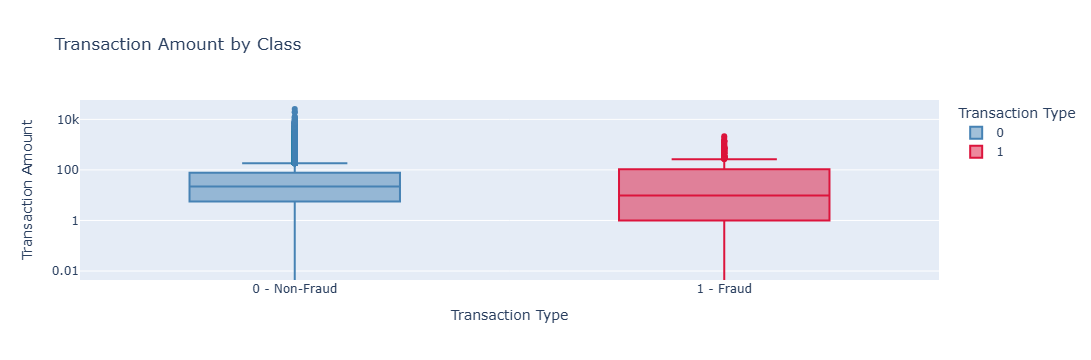

In [20]:
#Amount Distribution
fig = px.box(
    df_viz,
    x="Class",
    y="Amount",
    color="Class",
    title="Transaction Amount by Class",
    labels={"Class": "Transaction Type", "Amount": "Transaction Amount"},
    color_discrete_map={0: "steelblue", 1: "crimson"}
)

fig.update_xaxes(
    tickvals=[0, 1],
    ticktext=["0 - Non-Fraud", "1 - Fraud"]
)

fig.update_yaxes(type="log")

fig.show()

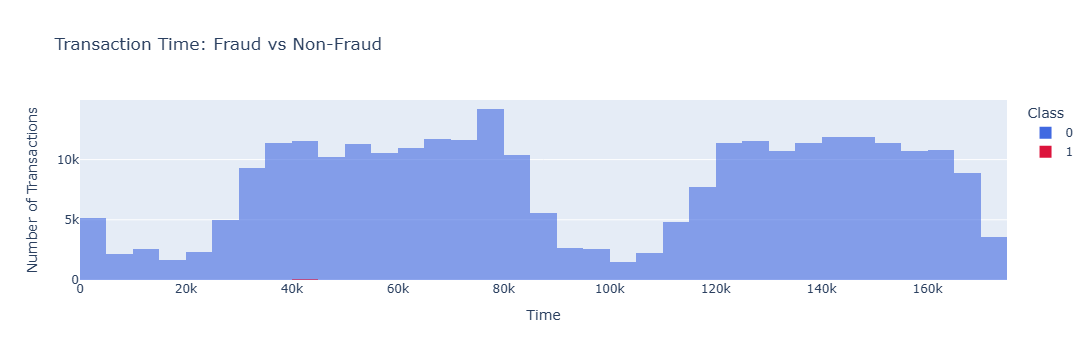

In [21]:
#Time Distribution
fig = px.histogram(
    df_viz,
    x="Time",
    color="Class",
    nbins=50,
    barmode="overlay",
    opacity=0.6,
    color_discrete_map={
        0: "royalblue",
        1: "crimson"
    },
    title="Transaction Time: Fraud vs Non-Fraud"
)

fig.update_xaxes(
    title="Time",
)

fig.update_yaxes(
    title="Number of Transactions"
)

fig.show()

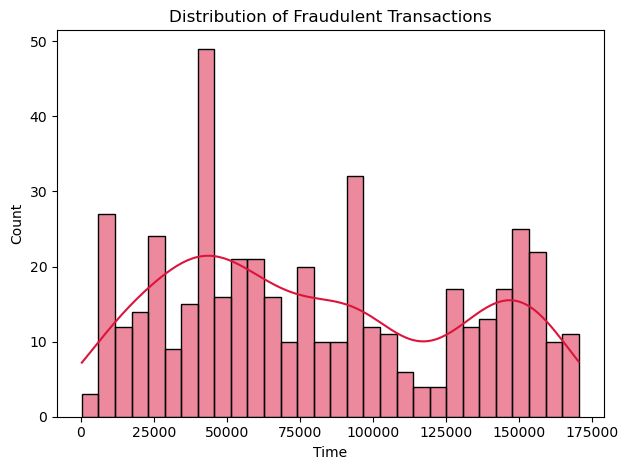

In [22]:
#Time Distribution - Fraud
df_fraud = df_viz[df_viz["Class"] == 1]

sns.histplot(
    data=df_fraud, 
    x="Time", 
    bins=30, 
    kde=True, 
    color="crimson", 
    edgecolor="black"
)

plt.title("Distribution of Fraudulent Transactions")
plt.tight_layout()
plt.show()

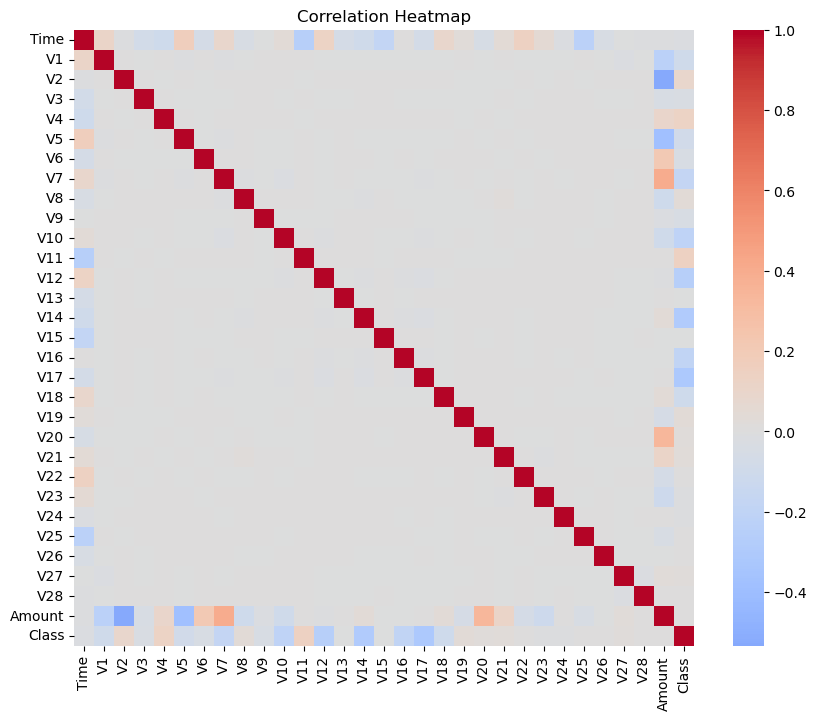

In [23]:
#Correlation Heatmap
corr = df_viz.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

As variables in PCA are uncorrelated (orthogonal) with each other so it is close to 0. Hence, opting for PCA components vs Class.

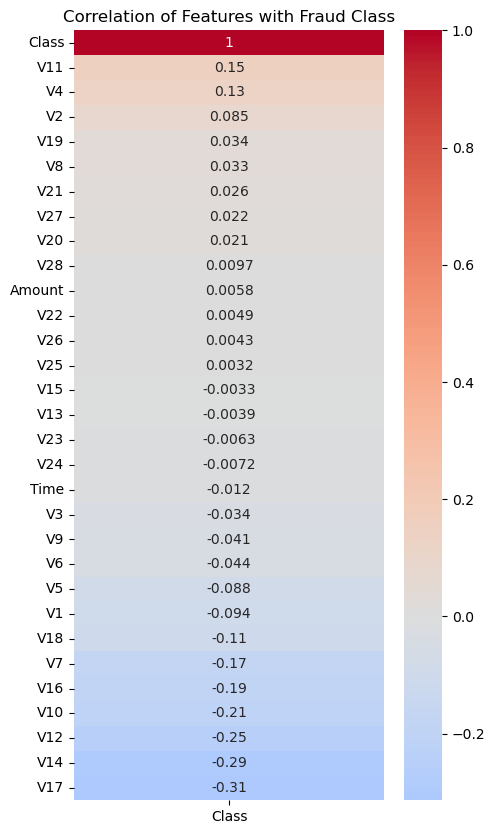

In [24]:
#PCA components vs Class
corr = df_viz.corr()[["Class"]].sort_values("Class", ascending=False)

plt.figure(figsize=(5, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation of Features with Fraud Class")
plt.show()

---------------------------------------------------

In [25]:
#Performing x/y split
#Independent Variables
x = df.drop(["Class"], axis = 1)
#Dependent Variable
y = df["Class"]

In [26]:
#Independent Variables
x.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99


In [27]:
#Dependent Variable
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Class, dtype: int64

In [28]:
#Question b: Perfroming train test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, stratify = y, random_state = 3)

In [29]:
#Creating a function to categorize columns as per skewness

def categorize_skew(val):
    abs_skew = abs(val)
    
    if abs_skew < 0.5:
        lvl = "Lightly skewed"
    elif abs_skew < 1:
        lvl = "Moderately skewed"
    else:
        lvl = "Highly skewed"
    
    return lvl

-----------------------
**Function to Handle Skewness & Outliers**

-----------------------

In [30]:
#Creating a function to check positive and negative skewness
def check_skew_dirn(val):
    if val > 0:
        return "Positive/Right"
    elif val < 0:
        return "Negative/Left"
    else:
        return "No Skew"

In [31]:
#Creating a function to categorize columns as per skewness
def categorize_skew(val):
    abs_skew = abs(val)
    
    if abs_skew < 0.5:
        lvl = "Lightly skewed"
    elif abs_skew < 1:
        lvl = "Moderately skewed"
    else:
        lvl = "Highly skewed"
    
    return lvl

In [32]:
#Handling Outliers using Capping & Flooring method

def manage_outliers(col_df, col_name):
    lower = col_df[col_name].quantile(0.01)
    upper = col_df[col_name].quantile(0.99)
    col_df[col_name] = col_df[col_name].clip(lower,upper)
    return col_df

----------------
**Methods to Handle Class Imbalance - SMOTE TOMEK** - This method is scrapped due to slow performance

----------------

#Handling Class Imbalance - Using SMOTE TOMEK
from imblearn.combine import SMOTETomek

smote_tomek = SMOTETomek(sampling_strategy=0.1,
    random_state=3,
    k_neighbors=3)
x_smote, y_smote = smote_tomek.fit_resample(x_train, y_train)

#Checking the Independent variables after SMOTE
x_smote.info()

#Checking Dependent Variables after SMOTE
y_smote.info()

#Checking Skewness - SMOTE Dataset
df_skewness_smote = x_smote.skew().to_frame(name="skewness").reset_index().rename(columns={"index": "column_name"})
df_skewness_smote

#Checking skewness of the columns

df_skewness_cpy_smote = df_skewness_smote.copy()
df_skewness_cpy_smote["skew_category"] = df_skewness_cpy_smote["skewness"].apply(categorize_skew)
df_skewness_cpy_smote

#Identifying highly and moderately skewed columns and converting it into a list
skewed_cols_smote = df_skewness_cpy_smote[
    df_skewness_cpy_smote["skew_category"].isin([
        "Highly skewed",
        "Moderately skewed"
    ])
]["column_name"].tolist()
skewed_cols_smote

#Since no categorical record present to not encoding categorical value
#Using Power Transformer to remove skewness
from sklearn.preprocessing import PowerTransformer
x_test_smote = x_test.copy()
pt_smote = PowerTransformer(method="yeo-johnson")
x_smote[skewed_cols_smote] = pt_smote.fit_transform(x_smote[skewed_cols_smote]) #for power transform
x_test_smote[skewed_cols_smote] = pt_smote.transform(x_test_smote[skewed_cols_smote])

#Treating Outliers for Training Dataset
#Note: Outliers should be handled in training dataset only
for col in x_smote.columns:
    x_smote = manage_outliers(x_smote, col)

#Since co categorical record present to not encoding categorical value
#Progressing towards Scaling using MinMax Scaler as all are numerical fields
from sklearn.preprocessing import MinMaxScaler

scaler_smote = MinMaxScaler()
x_smote_train_scaled = scaler_smote.fit_transform(x_smote)
x_smote_test_scaled = scaler_smote.transform(x_test_smote)

#Checking shape
x_smote_train_scaled.shape

#Checking shape
x_smote_test_scaled.shape

----------------
**Methods to Handle Class Imbalance - Random Undersampling**

----------------

In [33]:
#Using Random Undersampling

from imblearn.under_sampling import RandomUnderSampler

rand_us = RandomUnderSampler(random_state=3)

x_train_rand, y_train_rand = rand_us.fit_resample(x_train, y_train)

In [34]:
#Checking Skewness
df_skewness_rand = x_train_rand.skew().to_frame(name="skewness").reset_index().rename(columns={"index": "column_name"})
df_skewness_rand

,column_name,skewness
0,Time,0.120693
1,V1,-2.691378
2,V2,1.960546
3,V3,-2.227105
4,V4,0.866419
5,V5,-2.376447
6,V6,0.249198
7,V7,-2.946543
8,V8,-2.301405
9,V9,-1.403419


In [35]:
#Checking skewness of the columns

df_skewness_cpy_rand = df_skewness_rand.copy()
df_skewness_cpy_rand["skew_category"] = df_skewness_cpy_rand["skewness"].apply(categorize_skew)
df_skewness_cpy_rand

,column_name,skewness,skew_category
0,Time,0.120693,Lightly skewed
1,V1,-2.691378,Highly skewed
2,V2,1.960546,Highly skewed
3,V3,-2.227105,Highly skewed
4,V4,0.866419,Moderately skewed
5,V5,-2.376447,Highly skewed
6,V6,0.249198,Lightly skewed
7,V7,-2.946543,Highly skewed
8,V8,-2.301405,Highly skewed
9,V9,-1.403419,Highly skewed


In [36]:
#Checking skewness direction of the columns
df_skewness_cpy_rand["skew_direction"] = df_skewness_cpy_rand["skewness"].apply(check_skew_dirn)
df_skewness_cpy_rand

,column_name,skewness,skew_category,skew_direction
0,Time,0.120693,Lightly skewed,Positive/Right
1,V1,-2.691378,Highly skewed,Negative/Left
2,V2,1.960546,Highly skewed,Positive/Right
3,V3,-2.227105,Highly skewed,Negative/Left
4,V4,0.866419,Moderately skewed,Positive/Right
5,V5,-2.376447,Highly skewed,Negative/Left
6,V6,0.249198,Lightly skewed,Positive/Right
7,V7,-2.946543,Highly skewed,Negative/Left
8,V8,-2.301405,Highly skewed,Negative/Left
9,V9,-1.403419,Highly skewed,Negative/Left


In [37]:
#Identifying highly and moderately skewed columns and converting it into a list
skewed_cols_rand_under = df_skewness_cpy_rand[
    df_skewness_cpy_rand["skew_category"].isin([
        "Highly skewed",
        "Moderately skewed"
    ])
]["column_name"].tolist()
skewed_cols_rand_under

['V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V14',
 'V16',
 'V17',
 'V18',
 'V20',
 'V21',
 'V22',
 'V23',
 'V25',
 'V26',
 'V27',
 'V28',
 'Amount']

In [39]:
from sklearn.preprocessing import PowerTransformer

In [40]:
#Using Power Transformer to remove skewness
x_test_rand_under = x_test.copy()
x_train_rand_under = x_train_rand.copy()
pt_rand_under = PowerTransformer(method="yeo-johnson")
x_train_rand_under[skewed_cols_rand_under] = pt_rand_under.fit_transform(x_train_rand_under[skewed_cols_rand_under]) #for power transform
x_test_rand_under[skewed_cols_rand_under] = pt_rand_under.transform(x_test_rand_under[skewed_cols_rand_under])

In [41]:
#Treating Outliers for Training Dataset
#Note: Outliers should be handled in training dataset only
for col in x_train_rand_under.columns:
    x_train_rand_under = manage_outliers(x_train_rand_under, col)

In [43]:
from sklearn.preprocessing import MinMaxScaler

In [44]:
#Since co categorical record present to not encoding categorical value
#Progressing towards Scaling using MinMax Scaler as all are numerical fields
#from sklearn.preprocessing import MinMaxScaler

scaler_rand_under = MinMaxScaler()
x_rand_under_train_scaled = scaler_rand_under.fit_transform(x_train_rand_under)
x_rand_under_test_scaled = scaler_rand_under.transform(x_test_rand_under)

In [45]:
x_rand_under_train_scaled.shape

(756, 30)

In [46]:
y_train_rand.shape

(756,)

In [47]:
x_rand_under_test_scaled.shape

(56746, 30)

----------------
**Methods to Handle Class Imbalance - Random Oversampling**

----------------

In [48]:
from imblearn.over_sampling import RandomOverSampler

In [49]:
rand_os = RandomOverSampler(random_state=3)
x_train_rand_os, y_train_rand_os = rand_os.fit_resample(x_train, y_train)

In [50]:
#Checking Skewness
df_skewness_rand_os = x_train_rand_os.skew().to_frame(name="skewness").reset_index().rename(columns={"index": "column_name"})
df_skewness_rand_os

,column_name,skewness
0,Time,0.104649
1,V1,-2.687306
2,V2,1.528009
3,V3,253.360401
4,V4,0.852826
5,V5,-2.338065
6,V6,0.537618
7,V7,-2.844926
8,V8,-2.285725
9,V9,156.704389


In [51]:
#Checking skewness of the columns

df_skewness_rand_os_cpy = df_skewness_rand_os.copy()
df_skewness_rand_os_cpy["skew_category"] = df_skewness_rand_os_cpy["skewness"].apply(categorize_skew)
df_skewness_rand_os_cpy

,column_name,skewness,skew_category
0,Time,0.104649,Lightly skewed
1,V1,-2.687306,Highly skewed
2,V2,1.528009,Highly skewed
3,V3,253.360401,Highly skewed
4,V4,0.852826,Moderately skewed
5,V5,-2.338065,Highly skewed
6,V6,0.537618,Moderately skewed
7,V7,-2.844926,Highly skewed
8,V8,-2.285725,Highly skewed
9,V9,156.704389,Highly skewed


In [52]:
#Checking skewness direction of the columns
df_skewness_rand_os_cpy["skew_direction"] = df_skewness_rand_os_cpy["skewness"].apply(check_skew_dirn)
df_skewness_rand_os_cpy

,column_name,skewness,skew_category,skew_direction
0,Time,0.104649,Lightly skewed,Positive/Right
1,V1,-2.687306,Highly skewed,Negative/Left
2,V2,1.528009,Highly skewed,Positive/Right
3,V3,253.360401,Highly skewed,Positive/Right
4,V4,0.852826,Moderately skewed,Positive/Right
5,V5,-2.338065,Highly skewed,Negative/Left
6,V6,0.537618,Moderately skewed,Positive/Right
7,V7,-2.844926,Highly skewed,Negative/Left
8,V8,-2.285725,Highly skewed,Negative/Left
9,V9,156.704389,Highly skewed,Positive/Right


In [53]:
#Identifying highly and moderately skewed columns and converting it into a list
skewed_cols_rand_os = df_skewness_rand_os_cpy[
    df_skewness_rand_os_cpy["skew_category"].isin([
        "Highly skewed",
        "Moderately skewed"
    ])
]["column_name"].tolist()
skewed_cols_rand_os

['V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V14',
 'V16',
 'V17',
 'V18',
 'V20',
 'V21',
 'V22',
 'V23',
 'V25',
 'V26',
 'V27',
 'V28',
 'Amount']

In [54]:
#Using Power Transformer to remove skewness
x_test_rand_os = x_test.copy()
x_train_rand_os = x_train_rand_os.copy()
pt_rand_os = PowerTransformer(method="yeo-johnson")
x_train_rand_os[skewed_cols_rand_os] = pt_rand_os.fit_transform(x_train_rand_os[skewed_cols_rand_os]) #for power transform
x_test_rand_os[skewed_cols_rand_os] = pt_rand_os.transform(x_test_rand_os[skewed_cols_rand_os])

In [55]:
#Treating Outliers for Training Dataset
#Note: Outliers should be handled in training dataset only
for col in x_train_rand_os.columns:
    x_train_rand_os = manage_outliers(x_train_rand_os, col)

In [56]:
#Since co categorical record present to not encoding categorical value
#Progressing towards Scaling using MinMax Scaler as all are numerical fields
#from sklearn.preprocessing import MinMaxScaler

scaler_rand_os = MinMaxScaler()
x_train_rand_os = scaler_rand_os.fit_transform(x_train_rand_os)
x_test_rand_os = scaler_rand_os.transform(x_test_rand_os)

In [57]:
x_train_rand_os.shape

(453204, 30)

In [58]:
y_train_rand_os.shape

(453204,)

In [59]:
x_test_rand_os.shape

(56746, 30)

----------------
**Methods to Handle Class Imbalance - Undersampling + SMOTE**

----------------

In [68]:
from imblearn.pipeline import Pipeline
#from imblearn.combine import SMOTETomek
from imblearn.over_sampling import BorderlineSMOTE

In [69]:
#Creating pipeline of SMOTE and Undersampling
#used Random undersampling before SmoteTOMEK only for better performance - throws error The specified ratio required to remove samples from the minority class while trying to generate new samples. Please increase the ratio.
#instead of SMOTE TOMEK used BorderlineSMOTE
pipeline_smote_us = Pipeline([
    ("smote_us", BorderlineSMOTE(sampling_strategy=0.1, random_state=3)),
    ("under_us", RandomUnderSampler(sampling_strategy=1.0, random_state=3))
])

In [70]:
x_train_smote_us, y_train_smote_us = pipeline_smote_us.fit_resample(x_train, y_train)

In [71]:
#Checking Skewness
df_skewness_smote_us = x_train_smote_us.skew().to_frame(name="skewness").reset_index().rename(columns={"index": "column_name"})

In [72]:
#Checking skewness of the columns

df_skewness_smote_us_cpy = df_skewness_smote_us.copy()
df_skewness_smote_us_cpy["skew_category"] = df_skewness_smote_us_cpy["skewness"].apply(categorize_skew)

In [73]:
#Checking skewness direction of the columns
df_skewness_smote_us_cpy["skew_direction"] = df_skewness_smote_us_cpy["skewness"].apply(check_skew_dirn)
df_skewness_smote_us_cpy

,column_name,skewness,skew_category,skew_direction
0,Time,0.295895,Lightly skewed,Positive/Right
1,V1,-1.672969,Highly skewed,Negative/Left
2,V2,0.970179,Moderately skewed,Positive/Right
3,V3,-1.271921,Highly skewed,Negative/Left
4,V4,0.189825,Lightly skewed,Positive/Right
5,V5,-1.386458,Highly skewed,Negative/Left
6,V6,0.441153,Lightly skewed,Positive/Right
7,V7,-1.368765,Highly skewed,Negative/Left
8,V8,-0.252445,Lightly skewed,Negative/Left
9,V9,-0.638393,Moderately skewed,Negative/Left


In [74]:
#Identifying highly and moderately skewed columns and converting it into a list
skewed_cols_smote_us = df_skewness_smote_us_cpy[
    df_skewness_smote_us_cpy["skew_category"].isin([
        "Highly skewed",
        "Moderately skewed"
    ])
]["column_name"].tolist()
skewed_cols_smote_us

['V1',
 'V2',
 'V3',
 'V5',
 'V7',
 'V9',
 'V10',
 'V12',
 'V14',
 'V16',
 'V17',
 'V18',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V27',
 'V28',
 'Amount']

In [75]:
#Using Power Transformer to remove skewness
x_test_smote_us = x_test.copy()
x_train_smote_us = x_train_smote_us.copy()
pt_smote_us = PowerTransformer(method="yeo-johnson")
x_train_smote_us[skewed_cols_smote_us] = pt_smote_us.fit_transform(x_train_smote_us[skewed_cols_smote_us]) #for power transform
x_test_smote_us[skewed_cols_smote_us] = pt_smote_us.transform(x_test_smote_us[skewed_cols_smote_us])

In [76]:
#Treating Outliers for Training Dataset
#Note: Outliers should be handled in training dataset only
for col in x_train_smote_us.columns:
    x_train_smote_us = manage_outliers(x_train_smote_us, col)

In [77]:
#Since co categorical record present to not encoding categorical value
#Progressing towards Scaling using MinMax Scaler as all are numerical fields
#from sklearn.preprocessing import MinMaxScaler

scaler_smote_us = MinMaxScaler()
x_train_smote_us = scaler_smote_us.fit_transform(x_train_smote_us)
x_test_smote_us = scaler_smote_us.transform(x_test_smote_us)

In [78]:
x_train_smote_us.shape

(45320, 30)

In [79]:
y_train_smote_us.shape

(45320,)

In [80]:
x_test_smote_us.shape

(56746, 30)

In [81]:
y_test.shape

(56746,)

----------------
**Methods to Handle Class Imbalance - Borderline-SMOTE**

----------------

In [82]:
from imblearn.over_sampling import BorderlineSMOTE

In [83]:
smote_border = BorderlineSMOTE(random_state=3)

In [84]:
x_train_bs, y_train_bs = smote_border.fit_resample(x_train, y_train)

In [85]:
#Checking Skewness
df_skewness_bs = x_train_bs.skew().to_frame(name="skewness").reset_index().rename(columns={"index": "column_name"})

In [86]:
#Checking skewness of the columns

df_skewness_bs_cpy = df_skewness_bs.copy()
df_skewness_bs_cpy["skew_category"] = df_skewness_bs_cpy["skewness"].apply(categorize_skew)

In [87]:
#Checking skewness direction of the columns
df_skewness_bs_cpy["skew_direction"] = df_skewness_bs_cpy["skewness"].apply(check_skew_dirn)
df_skewness_bs_cpy

,column_name,skewness,skew_category,skew_direction
0,Time,0.307786,Lightly skewed,Positive/Right
1,V1,-1.666838,Highly skewed,Negative/Left
2,V2,1.003035,Highly skewed,Positive/Right
3,V3,156.120600,Highly skewed,Positive/Right
4,V4,0.175734,Lightly skewed,Positive/Right
5,V5,-1.393643,Highly skewed,Negative/Left
6,V6,0.509852,Moderately skewed,Positive/Right
7,V7,-1.362108,Highly skewed,Negative/Left
8,V8,-0.285085,Lightly skewed,Negative/Left
9,V9,121.225586,Highly skewed,Positive/Right


In [88]:
#Identifying highly and moderately skewed columns and converting it into a list
skewed_cols_bs = df_skewness_bs_cpy[
    df_skewness_bs_cpy["skew_category"].isin([
        "Highly skewed",
        "Moderately skewed"
    ])
]["column_name"].tolist()
skewed_cols_bs

['V1',
 'V2',
 'V3',
 'V5',
 'V6',
 'V7',
 'V9',
 'V10',
 'V12',
 'V14',
 'V16',
 'V17',
 'V18',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V27',
 'V28',
 'Amount']

In [89]:
#Using Power Transformer to remove skewness
x_test_bs = x_test.copy()
pt_bs = PowerTransformer(method="yeo-johnson")
x_train_bs[skewed_cols_bs] = pt_bs.fit_transform(x_train_bs[skewed_cols_bs]) #for power transform
x_test_bs[skewed_cols_bs] = pt_bs.transform(x_test_bs[skewed_cols_bs])

In [90]:
#Treating Outliers for Training Dataset
#Note: Outliers should be handled in training dataset only
for col in x_train_bs.columns:
    x_train_bs = manage_outliers(x_train_bs, col)

In [91]:
#Since co categorical record present to not encoding categorical value
#Progressing towards Scaling using MinMax Scaler as all are numerical fields
#from sklearn.preprocessing import MinMaxScaler

scaler_bs = MinMaxScaler()
x_train_bs = scaler_bs.fit_transform(x_train_bs)
x_test_bs = scaler_bs.transform(x_test_bs)

In [92]:
x_train_bs.shape

(453204, 30)

In [93]:
y_train_bs.shape

(453204,)

In [94]:
x_test_bs.shape

(56746, 30)

In [95]:
y_test.shape

(56746,)

----------------------
**Defining the ML Models**
----------------------
----------------------

In [96]:
#importing libraries for ML Classification Models

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, BaggingClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import KFold, GridSearchCV, RandomizedSearchCV

In [97]:
#Defining the models for evaluation

models_classifier = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=3),
    "Random Forest": RandomForestClassifier(random_state=3),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "AdaBoost": AdaBoostClassifier(random_state=3),
    "Bagging": BaggingClassifier(random_state=3),
    #"Gradient Boosting": GradientBoostingClassifier(random_state=3), #Rejected due to very high time consumption. Also, other models accuracy are above 90%
    "XGBoost": XGBClassifier(random_state=3, eval_metric="logloss")
}

In [98]:
#Defining the balanced models for evaluation

models_classifier_balanced = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=3),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=3),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(class_weight="balanced"),
    "Naive Bayes": GaussianNB(),
    "AdaBoost": AdaBoostClassifier(random_state=3),
    "Bagging": BaggingClassifier(random_state=3),
    #"Gradient Boosting": GradientBoostingClassifier(random_state=3), #Rejected due to very high time consumption. Also, other models accuracy are above 90%
    "XGBoost": XGBClassifier(random_state=3, eval_metric="logloss")
}

In [99]:
#Defining a function that takes predicted value and actual value as input and Classification Metrics Values

def classification_metrics_all(
    y_train_actual, y_train_predicted,
    y_test_actual, y_test_predicted,
    overfit_threshold
):

    # Accuracy
    train_acc = accuracy_score(y_train_actual, y_train_predicted)
    test_acc = accuracy_score(y_test_actual, y_test_predicted)

    # Precision (per class)
    train_precision = precision_score(y_train_actual, y_train_predicted, average=None, zero_division=0)
    test_precision = precision_score(y_test_actual, y_test_predicted, average=None, zero_division=0)

    # Recall (per class)
    train_recall = recall_score(y_train_actual, y_train_predicted, average=None, zero_division=0)
    test_recall = recall_score(y_test_actual, y_test_predicted, average=None, zero_division=0)

    # F1-score (per class)
    train_f1 = f1_score(y_train_actual, y_train_predicted, average=None, zero_division=0)
    test_f1 = f1_score(y_test_actual, y_test_predicted, average=None, zero_division=0)

    # Confusion Matrix
    train_cm = confusion_matrix(y_train_actual, y_train_predicted)
    test_cm = confusion_matrix(y_test_actual, y_test_predicted)

    # Overfitting check (based on accuracy gap)
    if (train_acc - test_acc) > overfit_threshold:
        overfit_flag = 'Y'
    else:
        overfit_flag = 'N'

    return (
        train_acc, test_acc,
        train_precision, test_precision,
        train_recall, test_recall,
        train_f1, test_f1,
        train_cm, test_cm,
        overfit_flag
    )


In [100]:
#Defining a function that takes the training and testing dataset and model name as input and returns the model performance metrics


def evaluate_classification_model(
    model, model_name,
    x_training, y_training,
    x_testing, y_testing,
    overfit_threshold=0.05
):

    # training the model
    model.fit(x_training, y_training)

    # predictions
    y_train_pred = model.predict(x_training)
    y_test_pred = model.predict(x_testing)

    # calling classification_metrics_all function
    (
        train_acc, test_acc,
        train_precision, test_precision,
        train_recall, test_recall,
        train_f1, test_f1,
        train_cm, test_cm,
        overfit_flag
    ) = classification_metrics_all(
        y_training, y_train_pred,
        y_testing, y_test_pred,
        overfit_threshold
    )

    return {
        "Model Name": model_name,

        "Train Accuracy": round(train_acc, 4),
        "Test Accuracy": round(test_acc, 4),

        "Train Precision (per class)": train_precision,
        "Test Precision (per class)": test_precision,

        "Train Recall (per class)": train_recall,
        "Test Recall (per class)": test_recall,

        "Train F1-score (per class)": train_f1,
        "Test F1-score (per class)": test_f1,

        "Train Confusion Matrix": train_cm,
        "Test Confusion Matrix": test_cm,

        "Overfitting (Y/N)": overfit_flag
    }

In [101]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [102]:
#Using Stratified K-Fold Cross Validation

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=3)

In [108]:
#Cross validating the performance of various models

def print_model_classifier_scores(model, model_name,  x_training, y_training):
    scores = cross_val_score(model, x_training, y_training, cv=skf, scoring='accuracy', n_jobs=-1)
    print(f"Model Name: {model_name} | Score: {np.mean(scores):.4f}")

------------------
**CV Scores using various dataset**
------------------
------------------

#Question c: Defining the classifier models for cross validation - SMOTE

print("******CV Scores**************************")
for name, model in models_classifier.items():
    print_model_classifier_scores(model, name, x_smote_train_scaled, y_smote)
print("********************************")

In [104]:
#Question c: Defining the classifier models for cross validation - Random Undersampling
#Using Class weight  = balanced only for undersampled cases for faster performance

print("******CV Scores**************************")
for name, model in models_classifier_balanced.items():
    print_model_classifier_scores(model, name, x_rand_under_train_scaled, y_train_rand)
print("********************************")

******CV Scores**************************
Model Name: Logistic Regression | Score: 0.9365
Model Name: Decision Tree | Score: 0.8875
Model Name: Random Forest | Score: 0.9445
Model Name: KNN | Score: 0.9325
Model Name: SVM | Score: 0.9405
Model Name: Naive Bayes | Score: 0.9206
Model Name: AdaBoost | Score: 0.9299
Model Name: Bagging | Score: 0.9325
Model Name: XGBoost | Score: 0.9352
********************************


#Question c: Defining the classifier models for cross validation - Random Over sampling
#Skipped due to performance issues
print("******CV Scores**************************")
for name, model in models_classifier.items():
    print_model_classifier_scores(model, name, x_train_rand_os, y_train_rand_os)
print("********************************")

In [106]:
#Question c: Defining the classifier models for cross validation - Smote + Undersampling

print("******CV Scores**************************")
for name, model in models_classifier_balanced.items():
    print_model_classifier_scores(model, name, x_train_smote_us, y_train_smote_us)
print("********************************")

******CV Scores**************************
Model Name: Logistic Regression | Score: 0.9963
Model Name: Decision Tree | Score: 0.9960
Model Name: Random Forest | Score: 0.9985
Model Name: KNN | Score: 0.9981
Model Name: SVM | Score: 0.9980
Model Name: Naive Bayes | Score: 0.9689
Model Name: AdaBoost | Score: 0.9954
Model Name: Bagging | Score: 0.9978
Model Name: XGBoost | Score: 0.9984
********************************


In [115]:
#model classifier for Borderline SMOTE for better performance
models_classifier_bs = {
    "Logistic Regression": LogisticRegression(max_iter=300),

    "Decision Tree": DecisionTreeClassifier(
        random_state=3,
        max_depth=5
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=30,
        random_state=3,
        max_depth=5,
        n_jobs=-1
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=3,
        n_jobs=-1
    ),

    "SVM": SVC(),

    "Naive Bayes": GaussianNB(),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=30,
        random_state=3
    ),

    "Bagging": BaggingClassifier(
        n_estimators=30,
        random_state=3,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=30,
        max_depth=6,
        learning_rate=0.1,
        random_state=3,
        eval_metric="logloss",
        n_jobs=-1,
        tree_method="hist"
    )
}

In [118]:
#model classifier for Borderline SMOTE for better performance 
models_classifier_bs_balanced = {
    "Logistic Regression": LogisticRegression(max_iter=300, class_weight="balanced"),

    "Decision Tree": DecisionTreeClassifier(
        random_state=3,
        class_weight="balanced",
        max_depth=5
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=30,
        random_state=3,
        max_depth=5,
        class_weight="balanced",
        n_jobs=-1
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=3,
        n_jobs=-1
    ),

    "SVM": SVC(class_weight="balanced"),

    "Naive Bayes": GaussianNB(),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=30,
        random_state=3
    ),

    "Bagging": BaggingClassifier(
        n_estimators=30,
        random_state=3,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=30,
        max_depth=6,
        learning_rate=0.1,
        random_state=3,
        eval_metric="logloss",
        n_jobs=-1,
        tree_method="hist"
    )
}

In [119]:
#Question c: Defining the classifier models for cross validation - Borderline-SMOTE
#Skipped due to performance issue and 
print("******CV Scores**************************")
for name, model in models_classifier_bs.items():
    if name in ("Logistic Regression","Decision Tree", "Random Forest", "XGBoost"):
        print_model_classifier_scores(model, name, x_train_bs, y_train_bs)
        
print("********************************")

******CV Scores**************************
Model Name: Logistic Regression | Score: 0.9972
Model Name: Decision Tree | Score: 0.9978
Model Name: Random Forest | Score: 0.9978
Model Name: XGBoost | Score: 0.9996
********************************


-------------------------------
**Comapring ML Models**
-------------------------------
-------------------------------

#comparing the models - smote

evaluation_results_smote = []

for name, model in models_classifier.items():
    print("Processing Model:", name)

    evaluation_results_smote.append(
        evaluate_classification_model(
            model,
            name,
            x_smote_train_scaled, 
            y_smote,
            x_smote_test_scaled,
            y_test
        )
    )

In [120]:
#comparing the models - Random Undersampling

evaluation_results_rand_us = []

for name, model in models_classifier.items():
    print("Processing Model:", name)

    evaluation_results_rand_us.append(
        evaluate_classification_model(
            model,
            name,
            x_rand_under_train_scaled,
            y_train_rand,
            x_rand_under_test_scaled,
            y_test
        )
    )

Processing Model: Logistic Regression
Processing Model: Decision Tree
Processing Model: Random Forest
Processing Model: KNN
Processing Model: SVM
Processing Model: Naive Bayes
Processing Model: AdaBoost
Processing Model: Bagging
Processing Model: XGBoost


In [123]:
#Based on CV score, restricting training to specific models for better performance 
models_classifier_rand_os_balanced = {
    "Logistic Regression": LogisticRegression(max_iter=300, class_weight="balanced"),

    "Decision Tree": DecisionTreeClassifier(
        random_state=3,
        class_weight="balanced",
        max_depth=5
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=30,
        random_state=3,
        max_depth=5,
        class_weight="balanced",
        n_jobs=-1
    ),

    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(
        n_estimators=30,
        max_depth=6,
        learning_rate=0.1,
        random_state=3,
        eval_metric="logloss",
        n_jobs=-1,
        tree_method="hist"
    )
}

In [124]:
#comparing the models - Random Oversampling

evaluation_results_rand_os = []

for name, model in models_classifier_rand_os_balanced.items():
    print("Processing Model:", name)

    evaluation_results_rand_os.append(
        evaluate_classification_model(
            model,
            name,
            x_train_rand_os,
            y_train_rand_os,
            x_test_rand_os,
            y_test
        )
    )

Processing Model: Logistic Regression
Processing Model: Decision Tree
Processing Model: Random Forest
Processing Model: Naive Bayes
Processing Model: XGBoost


In [125]:
#comparing the models - Smote + Undersampling

evaluation_results_rand_smote_us = []

for name, model in models_classifier.items():
    print("Processing Model:", name)

    evaluation_results_rand_smote_us.append(
        evaluate_classification_model(
            model,
            name,
            x_train_smote_us, 
            y_train_smote_us, 
            x_test_smote_us,  
            y_test
        )
    )

Processing Model: Logistic Regression
Processing Model: Decision Tree
Processing Model: Random Forest
Processing Model: KNN
Processing Model: SVM
Processing Model: Naive Bayes
Processing Model: AdaBoost
Processing Model: Bagging
Processing Model: XGBoost


In [126]:
#comparing the models - Borderline-SMOTE

evaluation_results_bs = []

for name, model in models_classifier_rand_os_balanced.items():
    print("Processing Model:", name)

    evaluation_results_bs.append(
        evaluate_classification_model(
            model,
            name,
            x_train_bs, 
            y_train_bs, 
            x_test_bs,  
            y_test
        )
    )

Processing Model: Logistic Regression
Processing Model: Decision Tree
Processing Model: Random Forest
Processing Model: Naive Bayes
Processing Model: XGBoost


In [128]:
#Performance of ML Model DF
#perf_ml_smote_df = pd.DataFrame(evaluation_results_smote)
perf_ml_rand_us_df = pd.DataFrame(evaluation_results_rand_us)
perf_ml_rand_os_df = pd.DataFrame(evaluation_results_rand_os)
perf_ml_smote_us_df = pd.DataFrame(evaluation_results_rand_smote_us)
perf_ml_bs_df = pd.DataFrame(evaluation_results_bs)

In [130]:
#perf_ml_smote_df

In [131]:
perf_ml_rand_us_df

,Model Name,Train Accuracy,Test Accuracy,Train Precision (per class),Test Precision (per class),Train Recall (per class),Test Recall (per class),Train F1-score (per class),Test F1-score (per class),Train Confusion Matrix,Test Confusion Matrix,Overfitting (Y/N)
0,Logistic Regression,0.9418,0.9871,"[0.9053398058252428, 0.9854651162790697]","[0.9997140406062339, 0.09949622166246852]","[0.9867724867724867, 0.8968253968253969]","[0.987378863568163, 0.8315789473684211]","[0.9443037974683545, 0.9390581717451524]","[0.9935081658570376, 0.17772778402699663]","[[373, 5], [39, 339]]","[[55936, 715], [16, 79]]",N
1,Decision Tree,1.0000,0.9066,"[1.0, 1.0]","[0.9997858714060462, 0.015627906976744186]","[1.0, 1.0]","[0.906603590404406, 0.8842105263157894]","[1.0, 1.0]","[0.9509174057136509, 0.030712979890310785]","[[378, 0], [0, 378]]","[[51360, 5291], [11, 84]]",Y
2,Random Forest,1.0000,0.9729,"[1.0, 1.0]","[0.9997461192514144, 0.05056179775280899]","[1.0, 1.0]","[0.9731514006813649, 0.8526315789473684]","[1.0, 1.0]","[0.9862695111588174, 0.09546258102533883]","[[378, 0], [0, 378]]","[[55130, 1521], [14, 81]]",N
3,KNN,0.9511,0.9779,"[0.9209876543209876, 0.9857549857549858]","[0.9997474155195122, 0.06141015921152388]","[0.9867724867724867, 0.9153439153439153]","[0.9781468994369031, 0.8526315789473684]","[0.9527458492975734, 0.9492455418381345]","[0.9888292082299827, 0.11456859971711457]","[[373, 5], [32, 346]]","[[55413, 1238], [14, 81]]",N
4,SVM,0.9550,0.9726,"[0.9236453201970444, 0.9914285714285714]","[0.9997641637791848, 0.05052372150338879]","[0.9920634920634921, 0.917989417989418]","[0.9727983619000548, 0.8631578947368421]","[0.9566326530612245, 0.9532967032967034]","[0.9860969456224167, 0.09545983701979045]","[[375, 3], [31, 347]]","[[55110, 1541], [13, 82]]",N
5,Naive Bayes,0.9206,0.9551,"[0.8840579710144928, 0.9649122807017544]","[0.9997967667436489, 0.032048836322014496]","[0.9682539682539683, 0.873015873015873]","[0.9552170305908104, 0.8842105263157894]","[0.9242424242424242, 0.9166666666666666]","[0.9769986278616307, 0.061855670103092786]","[[366, 12], [48, 330]]","[[54114, 2537], [11, 84]]",N
6,AdaBoost,0.9696,0.9572,"[0.9539641943734015, 0.9863013698630136]","[0.9998156444149475, 0.03395924890131842]","[0.9867724867724867, 0.9523809523809523]","[0.9573176113396057, 0.8947368421052632]","[0.9700910273081924, 0.9690444145356663]","[0.978105217595181, 0.06543494996150885]","[[373, 5], [18, 360]]","[[54233, 2418], [10, 85]]",N
7,Bagging,0.9907,0.9565,"[0.9818181818181818, 1.0]","[0.9997232982844494, 0.031545741324921134]","[1.0, 0.9814814814814815]","[0.9566468376551164, 0.8421052631578947]","[0.9908256880733946, 0.9906542056074766]","[0.9777108270717385, 0.06081337894336754]","[[378, 0], [7, 371]]","[[54195, 2456], [15, 80]]",N
8,XGBoost,1.0000,0.9653,"[1.0, 1.0]","[0.9997623661024385, 0.04019607843137255]","[1.0, 1.0]","[0.9654375033097385, 0.8631578947368421]","[1.0, 1.0]","[0.9823001697243999, 0.07681498829039812]","[[378, 0], [0, 378]]","[[54693, 1958], [13, 82]]",N


In [132]:
perf_ml_rand_os_df

,Model Name,Train Accuracy,Test Accuracy,Train Precision (per class),Test Precision (per class),Train Recall (per class),Test Recall (per class),Train F1-score (per class),Test F1-score (per class),Train Confusion Matrix,Test Confusion Matrix,Overfitting (Y/N)
0,Logistic Regression,0.9458,0.9720,"[0.9229980068003283, 0.9711789619015635]","[0.999764018225054, 0.049487024743512374]","[0.9727319264613729, 0.9188489068940257]","[0.9721981959718276, 0.8631578947368421]","[0.9472125892216392, 0.9442894914670041]","[0.9857884374440666, 0.09360730593607305]","[[220423, 6179], [18389, 208213]]","[[55076, 1575], [13, 82]]",N
1,Decision Tree,0.9662,0.9776,"[0.9564047060450125, 0.9763479845055624]","[0.9997473197848609, 0.06044776119402985]","[0.9768536906117333, 0.9554725907097025]","[0.9777762087165275, 0.8526315789473684]","[0.9665210490580702, 0.9657974970949619]","[0.9886397101475142, 0.11289198606271778]","[[221357, 5245], [10090, 216512]]","[[55392, 1259], [14, 81]]",N
2,Random Forest,0.9590,0.9967,"[0.9265972632407954, 0.9966334307489542]","[0.9996991097187561, 0.3157894736842105]","[0.9968888182805095, 0.9210289406095268]","[0.9970168222979294, 0.8210526315789474]","[0.9604586793198893, 0.9573408193314894]","[0.9983561643835617, 0.45614035087719296]","[[225897, 705], [17895, 208707]]","[[56482, 169], [17, 78]]",N
3,Naive Bayes,0.9147,0.9591,"[0.8777504441711084, 0.9597066909297252]","[0.9997608403701456, 0.03432398493093344]","[0.9636499236546897, 0.8657867097377782]","[0.9592769765758768, 0.8631578947368421]","[0.9186966216500484, 0.9103306513729966]","[0.9791006053617757, 0.06602254428341385]","[[218365, 8237], [30413, 196189]]","[[54344, 2307], [13, 82]]",N
4,XGBoost,0.9991,0.9980,"[1.0, 0.9981851339564961]","[0.999664174487866, 0.44970414201183434]","[0.9981818342291772, 1.0]","[0.9983583696669079, 0.8]","[0.9990900899309175, 0.9990917427956686]","[0.9990108453739358, 0.5757575757575758]","[[226190, 412], [0, 226602]]","[[56558, 93], [19, 76]]",N


In [133]:
perf_ml_smote_us_df

,Model Name,Train Accuracy,Test Accuracy,Train Precision (per class),Test Precision (per class),Train Recall (per class),Test Recall (per class),Train F1-score (per class),Test F1-score (per class),Train Confusion Matrix,Test Confusion Matrix,Overfitting (Y/N)
0,Logistic Regression,0.9964,0.9970,"[0.9959435626102293, 0.9968197879858657]","[0.9996991842584892, 0.33476394849785407]","[0.9968225948808473, 0.9959399823477494]","[0.9972639494448465, 0.8210526315789474]","[0.996382884869872, 0.9963796909492274]","[0.9984800820048779, 0.47560975609756095]","[[22588, 72], [92, 22568]]","[[56496, 155], [17, 78]]",N
1,Decision Tree,1.0000,0.9953,"[1.0, 1.0]","[0.999592415381889, 0.22784810126582278]","[1.0, 1.0]","[0.9956929268680165, 0.7578947368421053]","[1.0, 1.0]","[0.9976388606397184, 0.35036496350364965]","[[22660, 0], [0, 22660]]","[[56407, 244], [23, 72]]",N
2,Random Forest,1.0000,0.9993,"[1.0, 1.0]","[0.9996469612186899, 0.7894736842105263]","[1.0, 1.0]","[0.9996469612186899, 0.7894736842105263]","[1.0, 1.0]","[0.9996469612186899, 0.7894736842105263]","[[22660, 0], [0, 22660]]","[[56631, 20], [20, 75]]",N
3,KNN,0.9984,0.9985,"[0.9976645809465057, 0.9991602581101388]","[0.9996643346759946, 0.5352112676056338]","[0.9991615180935569, 0.9976610767872903]","[0.9988349720216766, 0.8]","[0.9984124884243948, 0.9984101046681093]","[0.9992494812591055, 0.6413502109704642]","[[22641, 19], [53, 22607]]","[[56585, 66], [19, 76]]",N
4,SVM,0.9984,0.9987,"[0.9974452715500154, 0.999336782066587]","[0.9996467554487972, 0.5859375]","[0.9993380406001765, 0.9974404236540159]","[0.9990644472295281, 0.7894736842105263]","[0.9983907589886031, 0.9983877023654394]","[0.9993555165137857, 0.672645739910314]","[[22645, 15], [58, 22602]]","[[56598, 53], [20, 75]]",N
5,Naive Bayes,0.9696,0.9780,"[0.9503173931443081, 0.9905947441217151]","[0.9996392626528624, 0.057515337423312884]","[0.9909973521624007, 0.9481906443071492]","[0.9783057668884927, 0.7894736842105263]","[0.9702311514365953, 0.9689289740698985]","[0.9888574665679392, 0.10721944245889921]","[[22456, 204], [1174, 21486]]","[[55422, 1229], [20, 75]]",N
6,AdaBoost,0.9956,0.9949,"[0.995980920413391, 0.9951935796807478]","[0.9996631145942304, 0.21902017291066284]","[0.995189761694616, 0.9959841129744043]","[0.9952163245132478, 0.8]","[0.9955851838770915, 0.9955886893996206]","[0.9974347633790358, 0.3438914027149321]","[[22551, 109], [91, 22569]]","[[56380, 271], [19, 76]]",N
7,Bagging,0.9997,0.9982,"[0.999382552703537, 1.0]","[0.9996642219669524, 0.4720496894409938]","[1.0, 0.9993821712268314]","[0.9984995851794319, 0.8]","[0.9996911810120439, 0.9996909901558293]","[0.9990815641668728, 0.59375]","[[22660, 0], [14, 22646]]","[[56566, 85], [19, 76]]",N
8,XGBoost,1.0000,0.9992,"[1.0, 1.0]","[0.9996645717110374, 0.7450980392156863]","[1.0, 1.0]","[0.9995410495842968, 0.8]","[1.0, 1.0]","[0.9996028068317225, 0.7715736040609137]","[[22660, 0], [0, 22660]]","[[56625, 26], [19, 76]]",N


In [134]:
perf_ml_bs_df

,Model Name,Train Accuracy,Test Accuracy,Train Precision (per class),Test Precision (per class),Train Recall (per class),Test Recall (per class),Train F1-score (per class),Test F1-score (per class),Train Confusion Matrix,Test Confusion Matrix,Overfitting (Y/N)
0,Logistic Regression,0.9972,0.9967,"[0.9974174921862584, 0.997075172048703]","[0.9996814159292036, 0.3130081300813008]","[0.9970741652765642, 0.9974183811263801]","[0.9970168222979294, 0.8105263157894737]","[0.9972457991816845, 0.9972467470581228]","[0.9983473411635779, 0.45161290322580644]","[[225939, 663], [585, 226017]]","[[56482, 169], [18, 77]]",N
1,Decision Tree,0.9980,0.9975,"[0.9978867305206408, 0.9981548593852768]","[0.9996109843863279, 0.37823834196891193]","[0.9981553560868837, 0.9978861616402327]","[0.9978817673121393, 0.7684210526315789]","[0.9980210252280675, 0.9980204924273353]","[0.9987456273629907, 0.5069444444444444]","[[226184, 418], [479, 226123]]","[[56531, 120], [22, 73]]",N
2,Random Forest,0.9976,0.9992,"[0.9958142622857118, 0.9994906207782429]","[0.9996645657892413, 0.7378640776699029]","[0.9994925022727073, 0.9957988014227589]","[0.9995233976452313, 0.8]","[0.9976499919610784, 0.9976412956736456]","[0.9995939767331015, 0.7676767676767676]","[[226487, 115], [952, 225650]]","[[56624, 27], [19, 76]]",N
3,Naive Bayes,0.9701,0.9779,"[0.9525939899137956, 0.9890328829883442]","[0.9995851520507918, 0.05521472392638037]","[0.9894572863434568, 0.9507594813814529]","[0.9782528110712961, 0.7578947368421053]","[0.9706757754241049, 0.9695186022702983]","[0.9888039395858795, 0.10293066476054324]","[[224213, 2389], [11158, 215444]]","[[55419, 1232], [23, 72]]",N
4,XGBoost,0.9996,0.9994,"[0.9994044231507339, 0.999708651719617]","[0.9996293550778355, 0.8409090909090909]","[0.9997087404347711, 0.9994042417983954]","[0.9997528728530829, 0.7789473684210526]","[0.9995565586302295, 0.9995564235823761]","[0.9996911101501205, 0.8087431693989071]","[[226536, 66], [135, 226467]]","[[56637, 14], [21, 74]]",N


-------------------------------------
**Hyperparameter Tune ML Models**
-------------------------------------
-------------------------------------

In [141]:
#Function to take different type of dataset as input and return the best model

def ht_ml_models(x_train, y_train, x_test, y_test):

    models = {
        "Logistic Regression": LogisticRegression(
            max_iter=500,
            class_weight="balanced"
        ),

        "Decision Tree": DecisionTreeClassifier(
            class_weight="balanced",
            random_state=3
        ),

        "Random Forest": RandomForestClassifier(
            class_weight="balanced",
            n_jobs=-1,
            random_state=3
        ),

        "Naive Bayes": GaussianNB(),
        "XGBoost": XGBClassifier(
            eval_metric="logloss",
            n_jobs=-1,
            random_state=3
        )
    }

    params = {
        "Logistic Regression": {
            "C": [0.1, 1, 10]
        },

        "Decision Tree": {
            "max_depth": [5, 10, None],
            "min_samples_split": [2, 5]
        },

        "Random Forest": {
            "n_estimators": [100, 150],
            "max_depth": [10, None],
            "min_samples_leaf": [1, 2]
        },

        "Naive Bayes": {
            "var_smoothing": [1e-9, 1e-8]
        },

        "XGBoost": {
            "n_estimators": [100, 200],
            "max_depth": [3, 5],
            "learning_rate": [0.05, 0.1]
        }
    }

    cv = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=3
    )

    best_models = {}
    results = []

    for name, model in models.items():

        print(f"Tuning {name}...")

        search = RandomizedSearchCV(
            estimator=model,
            param_distributions=params[name],
            n_iter=3,
            scoring="f1",
            cv=cv,
            random_state=3,
            n_jobs=-1
        )

        search.fit(x_train, y_train)

        best_model = search.best_estimator_

        y_pred = best_model.predict(x_test)

        results.append({
            "Model": name,
            "CV F1": round(search.best_score_, 4),
            "Test F1": round(f1_score(y_test, y_pred), 4),
            "Best Parameters": search.best_params_
        })

        best_models[name] = best_model

    return best_models, results
	

#Hyperparameter Tuned ML Models - SMOTE
best_models_smote_ht, results_smote_ht = ht_ml_models(
    x_smote_train_scaled, 
    y_smote,
    x_smote_test_scaled,
    y_test
)

results_smote_ht_df = pd.DataFrame(results_smote_ht).sort_values(
    "Test F1",
    ascending=False
)

results_smote_ht_df

#Best Hyperparametr Tuned SMOTE model

best_model_name_smote_ht = results_smote_ht_df.iloc[0]["Model"]
best_model_smote_ht = best_models_smote_ht[best_model_name_smote_ht]

print("Best Model:", best_model_name_smote_ht)
print(best_model_smote_ht)

----------------------

In [142]:
#Hyperparameter Tuned ML Models - Random Undersampling
best_models_rand_us_ht, results_rand_us_ht = ht_ml_models(
    x_rand_under_train_scaled,
    y_train_rand,
    x_rand_under_test_scaled,
    y_test
)

results_rand_us_ht_df = pd.DataFrame(results_rand_us_ht).sort_values(
    "Test F1",
    ascending=False
)

results_rand_us_ht_df

Tuning Logistic Regression...
Tuning Decision Tree...
Tuning Random Forest...
Tuning Naive Bayes...
Tuning XGBoost...


C:\Users\Dhrubajyoti Ghosh\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning:

The total space of parameters 2 is smaller than n_iter=3. Running 2 iterations. For exhaustive searches, use GridSearchCV.



,Model,CV F1,Test F1,Best Parameters
2,Random Forest,0.9381,0.0956,"{'n_estimators': 150, 'min_samples_leaf': 2, '..."
0,Logistic Regression,0.9313,0.0889,{'C': 10}
4,XGBoost,0.9373,0.0882,"{'n_estimators': 100, 'max_depth': 3, 'learnin..."
3,Naive Bayes,0.9166,0.0619,{'var_smoothing': 1e-09}
1,Decision Tree,0.9126,0.0307,"{'min_samples_split': 2, 'max_depth': None}"


In [143]:
#Best Hyperparametr Tuned Random Undersampling

best_model_name_rand_us_ht = results_rand_us_ht_df.iloc[0]["Model"]
best_model_rand_us_ht = best_models_rand_us_ht[best_model_name_rand_us_ht]

print("Best Model:", best_model_name_rand_us_ht)
print(best_model_rand_us_ht)

Best Model: Random Forest
RandomForestClassifier(class_weight='balanced', min_samples_leaf=2,
                       n_estimators=150, n_jobs=-1, random_state=3)


----------------------------------

In [145]:
#Hyperparameter Tuned ML Models - Random Over sampling
best_models_rand_os_ht, results_rand_os_ht = ht_ml_models(
    x_train_rand_os,
    y_train_rand_os,
    x_test_rand_os,
    y_test
)


Tuning Logistic Regression...
Tuning Decision Tree...
Tuning Random Forest...
Tuning Naive Bayes...


C:\Users\Dhrubajyoti Ghosh\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning:

The total space of parameters 2 is smaller than n_iter=3. Running 2 iterations. For exhaustive searches, use GridSearchCV.



Tuning XGBoost...


In [146]:

results_rand_os_ht_df = pd.DataFrame(results_rand_os_ht).sort_values(
    "Test F1",
    ascending=False
)

results_rand_os_ht_df

,Model,CV F1,Test F1,Best Parameters
2,Random Forest,0.9999,0.8439,"{'n_estimators': 150, 'min_samples_leaf': 1, '..."
4,XGBoost,0.9999,0.8242,"{'n_estimators': 200, 'max_depth': 5, 'learnin..."
1,Decision Tree,0.9998,0.7500,"{'min_samples_split': 5, 'max_depth': None}"
0,Logistic Regression,0.9451,0.1062,{'C': 0.1}
3,Naive Bayes,0.9103,0.0660,{'var_smoothing': 1e-09}


In [147]:
#Best Hyperparameter Tuned Random Over sampling

best_model_name_rand_os_ht = results_rand_os_ht_df.iloc[0]["Model"]
best_model_rand_os_ht = best_models_rand_os_ht[best_model_name_rand_os_ht]

print("Best Model:", best_model_name_rand_os_ht)
print(best_model_rand_os_ht)

Best Model: Random Forest
RandomForestClassifier(class_weight='balanced', n_estimators=150, n_jobs=-1,
                       random_state=3)


---------------------------------------------------------

In [148]:
#Hyperparameter Tuned ML Models - Smote + Undersampling
best_models_smote_us_ht, results_smote_us_ht = ht_ml_models(
    x_train_smote_us, 
    y_train_smote_us, 
    x_test_smote_us,  
    y_test
)



Tuning Logistic Regression...
Tuning Decision Tree...
Tuning Random Forest...
Tuning Naive Bayes...


C:\Users\Dhrubajyoti Ghosh\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning:

The total space of parameters 2 is smaller than n_iter=3. Running 2 iterations. For exhaustive searches, use GridSearchCV.



Tuning XGBoost...


In [149]:
results_smote_us_ht_df = pd.DataFrame(results_smote_us_ht).sort_values(
    "Test F1",
    ascending=False
)

results_smote_us_ht_df

,Model,CV F1,Test F1,Best Parameters
2,Random Forest,0.9985,0.7895,"{'n_estimators': 100, 'min_samples_leaf': 1, '..."
4,XGBoost,0.9985,0.7600,"{'n_estimators': 200, 'max_depth': 5, 'learnin..."
0,Logistic Regression,0.9963,0.4756,{'C': 1}
1,Decision Tree,0.9967,0.4717,"{'min_samples_split': 5, 'max_depth': 10}"
3,Naive Bayes,0.9684,0.1072,{'var_smoothing': 1e-09}


In [150]:
#Best Hyperparametr Tuned Smote + Undersampling

best_model_name_smote_us_ht = results_smote_us_ht_df.iloc[0]["Model"]
best_model_smote_us_ht = best_models_smote_us_ht[best_model_name_smote_us_ht]

print("Best Model:", best_model_name_smote_us_ht)
print(best_model_smote_us_ht)

Best Model: Random Forest
RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=3)


----------------------------------------------

In [151]:
#Hyperparameter Tuned ML Models - Borderline-SMOTE
best_models_bs_ht, results_bs_ht = ht_ml_models(
    x_train_bs, 
    y_train_bs, 
    x_test_bs,  
    y_test
)



Tuning Logistic Regression...
Tuning Decision Tree...
Tuning Random Forest...
Tuning Naive Bayes...


C:\Users\Dhrubajyoti Ghosh\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning:

The total space of parameters 2 is smaller than n_iter=3. Running 2 iterations. For exhaustive searches, use GridSearchCV.



Tuning XGBoost...


In [152]:
results_bs_ht_df = pd.DataFrame(results_bs_ht).sort_values(
    "Test F1",
    ascending=False
)

results_bs_ht_df

,Model,CV F1,Test F1,Best Parameters
2,Random Forest,0.9998,0.8555,"{'n_estimators': 150, 'min_samples_leaf': 1, '..."
4,XGBoost,0.9998,0.8343,"{'n_estimators': 200, 'max_depth': 5, 'learnin..."
1,Decision Tree,0.9995,0.7486,"{'min_samples_split': 5, 'max_depth': None}"
0,Logistic Regression,0.9974,0.4516,{'C': 10}
3,Naive Bayes,0.9695,0.1029,{'var_smoothing': 1e-09}


In [153]:
#Best Hyperparametr Tuned Borderline-SMOTE

best_model_name_bs_ht = results_bs_ht_df.iloc[0]["Model"]
best_model_bs_ht = best_models_bs_ht[best_model_name_bs_ht]

print("Best Model:", best_model_name_bs_ht)
print(best_model_bs_ht)

Best Model: Random Forest
RandomForestClassifier(class_weight='balanced', n_estimators=150, n_jobs=-1,
                       random_state=3)


-------------------------------------------------------

In [160]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_curve,
    auc,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score
)

In [165]:
#Saving models - XGBoost trained on Borderline-SMOTE dataset

xgb_model_final = XGBClassifier(
    n_estimators=50,
    max_depth=6,
    learning_rate=0.1,
    random_state=3,
    eval_metric="logloss",
    n_jobs=-1,
    tree_method="hist"
)

xgb_model_final.fit(x_train_bs, y_train_bs)
y_pred_bs = xgb_model_final.predict(x_test_bs)

accuracy_bs = accuracy_score(y_test, y_pred_bs)

print(f"XGBoost Accuracy: {accuracy_bs:.4f}")
#with open("xgboost_model.pkl", "wb") as file:
#    pickle.dump(xgb_model, file)
pickle.dump(xgb_model_final, open("ml_borderline_smote_xgb_model.pkl", "wb"))

XGBoost Accuracy: 0.9995


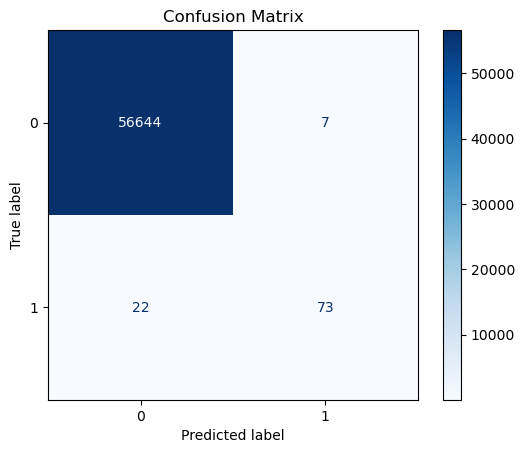

In [236]:
from sklearn.metrics import ConfusionMatrixDisplay

#ConfusionMatrixDisplay.from_estimator(random_xgb_org.best_estimator_, x_test_scaled_org, y_test)
#plt.show()

ConfusionMatrixDisplay.from_estimator(
    xgb_model_final,
    x_test_bs,
    y_test,
    cmap='Blues' 
)

plt.title("Confusion Matrix")
plt.show()

-------------------------------

In [161]:
#Precision recall curve for hyperparameter tuned ML model

def plot_ht_tuned_performance(
    model_data,
    threshold=0.5
):

    predictions = {}

    for name, data in model_data.items():

        model = data["model"]
        x_test = data["x_test"]
        y_test = data["y_test"]

        # Predicted probabilities
        y_prob = model.predict(
            x_test
        ).ravel()

        # Convert probability to class
        y_pred = (
            y_prob >= threshold
        ).astype(int)

        predictions[name] = {
            "y_test": np.asarray(y_test),
            "y_prob": y_prob,
            "y_pred": y_pred
        }

    plt.figure(figsize=(9, 7))

    for name, data in predictions.items():

        y_test = data["y_test"]
        y_prob = data["y_prob"]

        fpr, tpr, _ = roc_curve(
            y_test,
            y_prob
        )

        roc_auc = auc(
            fpr,
            tpr
        )

        plt.plot(
            fpr,
            tpr,
            linewidth=2,
            label=f"{name} (AUC = {roc_auc:.4f})"
        )

    plt.plot(
        [0, 1],
        [0, 1],
        "--",
        color="gray",
        linewidth=1.5,
        label="Random Classifier"
    )

    plt.xlabel(
        "False Positive Rate",
        fontsize=12
    )

    plt.ylabel(
        "True Positive Rate",
        fontsize=12
    )

    plt.title(
        "ROC-AUC Curve - Hyperparameter Tuned Models",
        fontsize=14,
        fontweight="bold"
    )

    plt.legend(
        loc="lower right"
    )

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()

    n_models = len(predictions)

    fig, axes = plt.subplots(
        1,
        n_models,
        figsize=(5 * n_models, 4)
    )

    if n_models == 1:
        axes = [axes]

    for ax, (name, data) in zip(
        axes,
        predictions.items()
    ):

        y_test = data["y_test"]
        y_pred = data["y_pred"]

        cm = confusion_matrix(
            y_test,
            y_pred
        )

        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            ax=ax
        )

        ax.set_title(
            name,
            fontsize=11,
            fontweight="bold"
        )

        ax.set_xlabel(
            "Predicted Label"
        )

        ax.set_ylabel(
            "True Label"
        )

        ax.set_xticklabels(
            ["Legitimate", "Fraud"]
        )

        ax.set_yticklabels(
            ["Legitimate", "Fraud"],
            rotation=0
        )

    fig.suptitle(
        f"Confusion Matrix - Hyperparameter Tuned Models\n"
        f"Threshold = {threshold}",
        fontsize=15,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9, 7))

    for name, data in predictions.items():

        y_test = data["y_test"]
        y_prob = data["y_prob"]

        precision, recall, _ = precision_recall_curve(
            y_test,
            y_prob
        )

        pr_auc = average_precision_score(
            y_test,
            y_prob
        )

        plt.plot(
            recall,
            precision,
            linewidth=2,
            label=f"{name} (AP = {pr_auc:.4f})"
        )

    # Fraud prevalence baseline
    y_test_reference = next(
        iter(predictions.values())
    )["y_test"]

    fraud_rate = np.mean(
        y_test_reference
    )

    plt.axhline(
        y=fraud_rate,
        linestyle="--",
        color="gray",
        linewidth=1.5,
        label=f"Fraud prevalence = {fraud_rate:.4f}"
    )

    plt.xlabel(
        "Recall",
        fontsize=12
    )

    plt.ylabel(
        "Precision",
        fontsize=12
    )

    plt.title(
        "Precision-Recall Curve - Hyperparameter Tuned Models",
        fontsize=14,
        fontweight="bold"
    )

    plt.legend(
        loc="best"
    )

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()

---------------------------------------------------

In [233]:
#Defining the models
models_ht_ml = {

#    "SMOTE": {
#        "model": best_model_smote_ht,
#        "x_test": x_smote_test_scaled,
#        "y_test": y_test
#    },

    "Random Undersampling": {
        "model": best_model_rand_us_ht,
        "x_test": x_rand_under_test_scaled,
        "y_test": y_test
    },

    "Random Oversampling": {
        "model": best_model_rand_os_ht,
        "x_test": x_test_rand_os,
        "y_test": y_test
    },

    "SMOTE + Undersampling": {
        "model": best_model_smote_us_ht,
        "x_test": x_test_smote_us,
        "y_test": y_test
    },

    "Borderline-SMOTE": {
        "model": best_model_bs_ht,
        "x_test": x_test_bs,
        "y_test": y_test
    },

    "Borderline-SMOTE_ML_Model": {
        "model": xgb_model_final,
        "x_test": x_test_bs,
        "y_test": y_test
    }

    
}

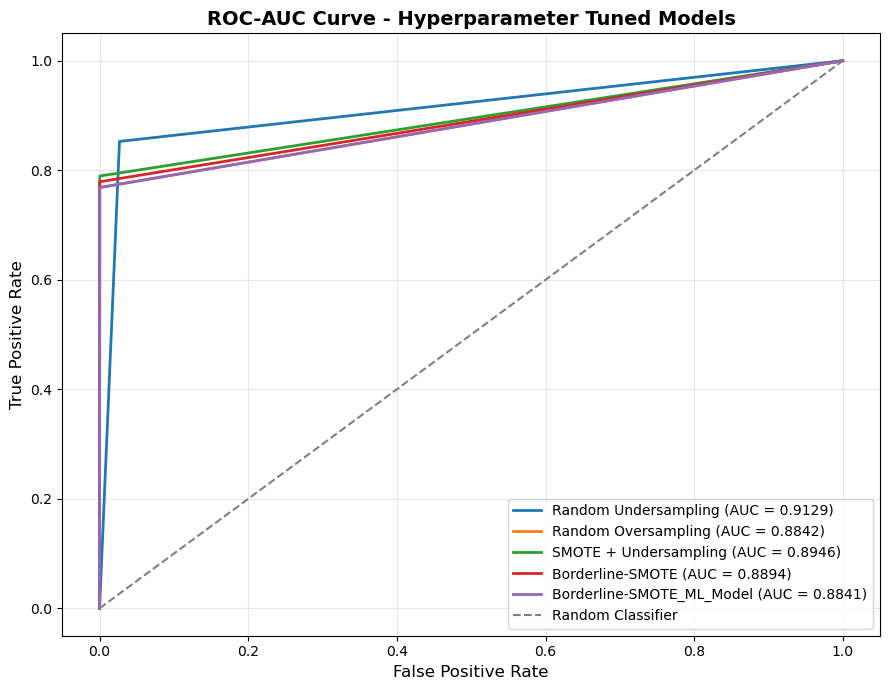

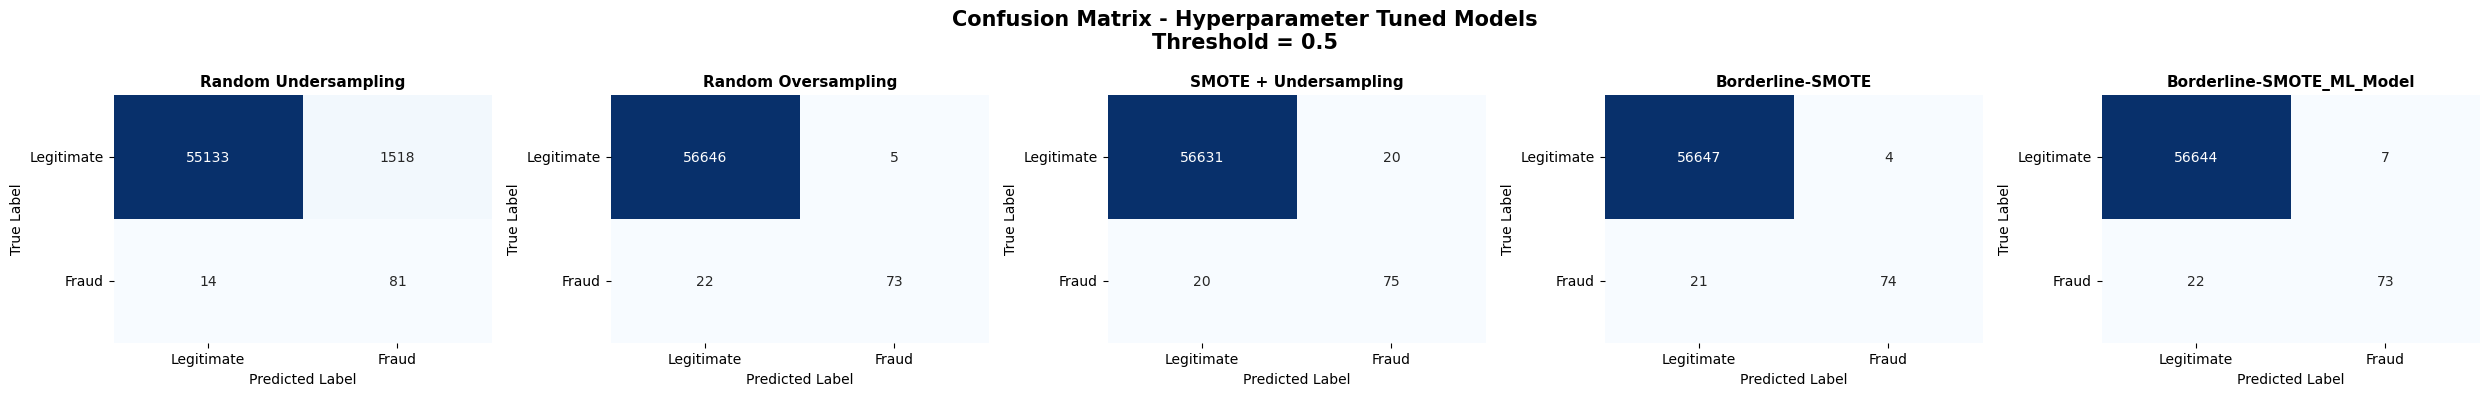

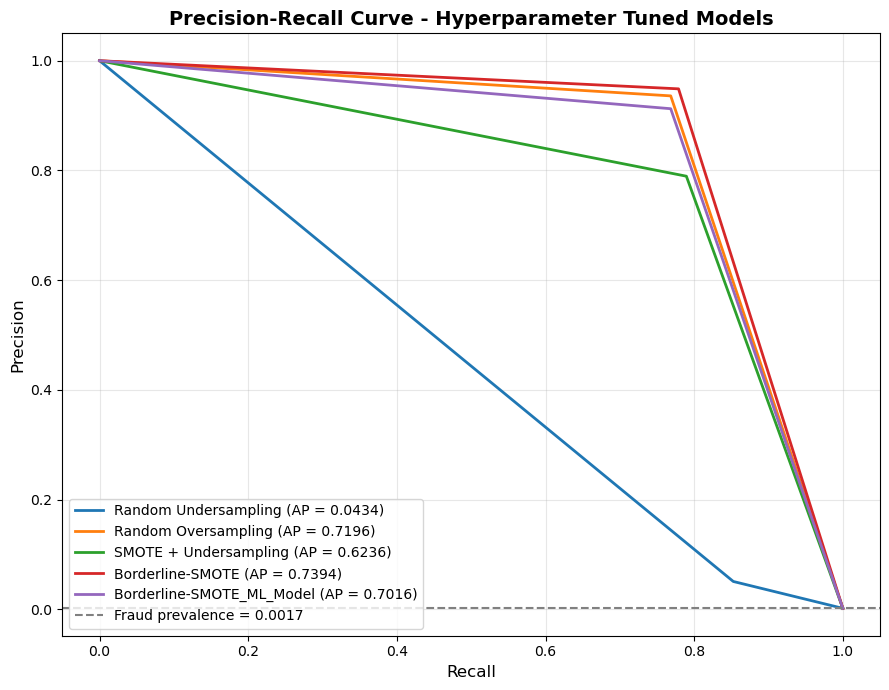

In [234]:
#Comparing the results
plot_ht_tuned_performance(
    model_data=models_ht_ml,
    threshold=0.5
)

------------
**Save ML Models**

------------

#Saving all ML Models. However, based on performance and accuracy the best will be selected

#Sample

import pickle

#pickle.dump(le_type, open("le_predictivemaintenance.pkl", "wb")) #label_encoder

#pickle.dump(pt, open("powertransformer_predictivemaintenance.pkl", "wb")) 

#pickle.dump(scaler, open("scaler_predictivemaintenance.pkl", "wb"))

#pickle.dump(XGBoost_Smote, open("best_model_predictivemaintenance.pkl", "wb")) #XGBoost Model


In [164]:
#Saving models - Hyperparameter tuned ML Models

#pickle.dump(best_model_rand_us_ht, open("ml_ht_best_model_rand_us.pkl", "wb"))  --Best
#pickle.dump(best_model_rand_os_ht, open("ml_ht_best_model_rand_os.pkl", "wb"))
#pickle.dump(best_model_rand_os_ht, open("best_model_name_smote_us_ht.pkl", "wb"))
pickle.dump(best_model_rand_os_ht, open("best_model_bs_ht.pkl", "wb"))

-----------------------------
**ANN Model**
-----------------------------
-----------------------------

In [175]:
#importing libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam



In [176]:
#building an ann model

def create_ann(input_dim, learning_rate=0.001):
    model = Sequential([
        Dense(128, activation="relu", input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.3),

        Dense(64, activation="relu"),
        BatchNormalization(),
        Dropout(0.3),

        Dense(32, activation="relu"),
        Dropout(0.2),

        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc")
        ]
    )

    return model

In [177]:
#creating the models
#model_smote = create_ann(x_smote_train_scaled.shape[1])

model_rand_us = create_ann(x_rand_under_train_scaled.shape[1])

model_rand_os = create_ann(x_train_rand_os.shape[1])

model_smote_us = create_ann(x_train_smote_us.shape[1])

model_bs = create_ann(x_train_bs.shape[1])

In [178]:
#Adding early stopping 
#early_stopping = EarlyStopping(
#    monitor='val_loss',
#    patience=5,
#    restore_best_weights=True
#)
def get_early_stopping():
    return tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

------------------------------

#DL - SMOTE
history_smote = model_smote.fit(
    x_smote_train_scaled,
    y_smote,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[get_early_stopping()],
    verbose=1
)

In [181]:
#DL - Random Undersampling
history_rand_us = model_rand_us.fit(
    x_rand_under_train_scaled,
    y_train_rand,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[get_early_stopping()],
    verbose=1
)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8990 - auc: 0.9430 - loss: 0.2971 - precision: 0.8837 - recall: 0.8407 - val_accuracy: 0.1645 - val_auc: 0.0000e+00 - val_loss: 0.7947 - val_precision: 1.0000 - val_recall: 0.1645
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9255 - auc: 0.9534 - loss: 0.2410 - precision: 0.9372 - recall: 0.8584 - val_accuracy: 0.1711 - val_auc: 0.0000e+00 - val_loss: 0.8698 - val_precision: 1.0000 - val_recall: 0.1711
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9371 - auc: 0.9637 - loss: 0.1965 - precision: 0.9796 - recall: 0.8496 - val_accuracy: 0.2105 - val_auc: 0.0000e+00 - val_loss: 0.9200 - val_precision: 1.0000 - val_recall: 0.2105
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9387 - auc: 0.9642 - loss: 0.1841 - precision: 0.9749 - recall: 0.8584 - val_accuracy: 0.3092 - val_auc: 0.0000e+00 - val_loss: 0.9195 - val_precision: 1.0000 - val_recall: 0.3092
Epoch 5/50
10/10 ━━━

In [182]:
#DL - Random Oversampling
history_rand_os = model_rand_os.fit(
    x_train_rand_os,
    y_train_rand_os,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[get_early_stopping()],
    verbose=1
)

Epoch 1/50
5666/5666 ━━━━━━━━━━━━━━━━━━━━ 34s 5ms/step - accuracy: 0.9650 - auc: 0.9935 - loss: 0.0922 - precision: 0.9667 - recall: 0.9391 - val_accuracy: 0.9874 - val_auc: 0.0000e+00 - val_loss: 0.0365 - val_precision: 1.0000 - val_recall: 0.9874
Epoch 2/50
5666/5666 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - accuracy: 0.9770 - auc: 0.9973 - loss: 0.0598 - precision: 0.9704 - recall: 0.9683 - val_accuracy: 0.9974 - val_auc: 0.0000e+00 - val_loss: 0.0252 - val_precision: 1.0000 - val_recall: 0.9974
Epoch 3/50
5666/5666 ━━━━━━━━━━━━━━━━━━━━ 29s 5ms/step - accuracy: 0.9805 - auc: 0.9980 - loss: 0.0519 - precision: 0.9730 - recall: 0.9752 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 0.0143 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 4/50
5666/5666 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - accuracy: 0.9827 - auc: 0.9983 - loss: 0.0467 - precision: 0.9745 - recall: 0.9795 - val_accuracy: 0.9898 - val_auc: 0.0000e+00 - val_loss: 0.0393 - val_precision: 1.0000 - val_recall: 0.9898
Epoc

In [183]:
#DL - Smote + Undersampling
history_smote_us = model_smote_us.fit(
    x_train_smote_us,
    y_train_smote_us,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[get_early_stopping()],
    verbose=1
)

ERROR! Session/line number was not unique in database. History logging moved to new session 126
Epoch 1/50
567/567 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9841 - auc: 0.9973 - loss: 0.0516 - precision: 0.9814 - recall: 0.9760 - val_accuracy: 0.9946 - val_auc: 0.0000e+00 - val_loss: 0.0188 - val_precision: 1.0000 - val_recall: 0.9946
Epoch 2/50
567/567 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9937 - auc: 0.9983 - loss: 0.0258 - precision: 0.9933 - recall: 0.9898 - val_accuracy: 0.9985 - val_auc: 0.0000e+00 - val_loss: 0.0057 - val_precision: 1.0000 - val_recall: 0.9985
Epoch 3/50
567/567 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9947 - auc: 0.9985 - loss: 0.0225 - precision: 0.9948 - recall: 0.9911 - val_accuracy: 0.9977 - val_auc: 0.0000e+00 - val_loss: 0.0094 - val_precision: 1.0000 - val_recall: 0.9977
Epoch 4/50
567/567 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9951 - auc: 0.9985 - loss: 0.0206 - precision: 0.9947 - recall: 0.9923 - val_accuracy: 0.9991 - val_

In [184]:
#DL - Borderline-SMOTE
history_bs = model_bs.fit(
    x_train_bs,
    y_train_bs,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[get_early_stopping()],
    verbose=1
)

Epoch 1/50
5666/5666 ━━━━━━━━━━━━━━━━━━━━ 33s 5ms/step - accuracy: 0.9952 - auc: 0.9995 - loss: 0.0156 - precision: 0.9930 - recall: 0.9942 - val_accuracy: 0.9990 - val_auc: 0.0000e+00 - val_loss: 0.0029 - val_precision: 1.0000 - val_recall: 0.9990
Epoch 2/50
5666/5666 ━━━━━━━━━━━━━━━━━━━━ 41s 5ms/step - accuracy: 0.9979 - auc: 0.9996 - loss: 0.0086 - precision: 0.9971 - recall: 0.9974 - val_accuracy: 0.9985 - val_auc: 0.0000e+00 - val_loss: 0.0049 - val_precision: 1.0000 - val_recall: 0.9985
Epoch 3/50
5666/5666 ━━━━━━━━━━━━━━━━━━━━ 29s 5ms/step - accuracy: 0.9984 - auc: 0.9997 - loss: 0.0074 - precision: 0.9977 - recall: 0.9980 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 7.0851e-04 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 4/50
5666/5666 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - accuracy: 0.9985 - auc: 0.9997 - loss: 0.0066 - precision: 0.9979 - recall: 0.9982 - val_accuracy: 0.9997 - val_auc: 0.0000e+00 - val_loss: 8.8868e-04 - val_precision: 1.0000 - val_recall: 0.9

-----------------------------------------------

In [187]:
#Checking the imbalance after borderline smote
from collections import Counter

print("Before:", Counter(y_train))
print("Borderline SMOTE:", Counter(y_train_bs))
print("SMOTE US:", Counter(y_train_smote_us))
print("Random Undersampling:", Counter(y_train_rand))
print("Random Oversampling:", Counter(y_train_rand_os))

Before: Counter({0: 226602, 1: 378})
Borderline SMOTE: Counter({0: 226602, 1: 226602})
SMOTE US: Counter({0: 22660, 1: 22660})
Random Undersampling: Counter({0: 378, 1: 378})
Random Oversampling: Counter({0: 226602, 1: 226602})


Since borderline Oversampling is still unbalanced. Hence, adding class weight to it.

In [188]:
#Adding Class weight
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train_bs)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_bs
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0)}


In [189]:
#Retraining DL - Borderline-SMOTE
history_bs_new = model_bs.fit(
    x_train_bs,
    y_train_bs,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[get_early_stopping()],
    verbose=1
)

Epoch 1/50
5666/5666 ━━━━━━━━━━━━━━━━━━━━ 32s 5ms/step - accuracy: 0.9989 - auc: 0.9997 - loss: 0.0058 - precision: 0.9984 - recall: 0.9986 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 1.9704e-04 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 2/50
5666/5666 ━━━━━━━━━━━━━━━━━━━━ 30s 5ms/step - accuracy: 0.9990 - auc: 0.9997 - loss: 0.0053 - precision: 0.9986 - recall: 0.9988 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 1.1863e-04 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 3/50
5666/5666 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - accuracy: 0.9990 - auc: 0.9997 - loss: 0.0052 - precision: 0.9985 - recall: 0.9987 - val_accuracy: 0.9999 - val_auc: 0.0000e+00 - val_loss: 4.4616e-04 - val_precision: 1.0000 - val_recall: 0.9999
Epoch 4/50
5666/5666 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - accuracy: 0.9990 - auc: 0.9997 - loss: 0.0052 - precision: 0.9986 - recall: 0.9987 - val_accuracy: 0.9998 - val_auc: 0.0000e+00 - val_loss: 6.1585e-04 - val_precision: 1.0000 - val_rec

---------------------------

In [190]:
#Compare histories of different models
def compare_histories(histories):
    results = []

    for name, history in histories.items():

        h = history.history

        # Number of epochs actually completed
        epochs = len(h["loss"])

        # Best validation loss
        best_val_loss = min(h["val_loss"])
        best_val_loss_epoch = np.argmin(h["val_loss"]) + 1

        # Best validation accuracy
        best_val_accuracy = max(h["val_accuracy"])
        best_val_accuracy_epoch = np.argmax(h["val_accuracy"]) + 1

        # Final metrics
        final_train_loss = h["loss"][-1]
        final_val_loss = h["val_loss"][-1]
        final_train_accuracy = h["accuracy"][-1]
        final_val_accuracy = h["val_accuracy"][-1]

        results.append({
            "Method": name,
            "Epochs": epochs,
            "Best Val Loss": best_val_loss,
            "Best Val Loss Epoch": best_val_loss_epoch,
            "Best Val Accuracy": best_val_accuracy,
            "Best Val Accuracy Epoch": best_val_accuracy_epoch,
            "Final Train Loss": final_train_loss,
            "Final Val Loss": final_val_loss,
            "Final Train Accuracy": final_train_accuracy,
            "Final Val Accuracy": final_val_accuracy
        })

    results_df = pd.DataFrame(results)

    return results_df

In [191]:
#defining the histories

histories_dl = {
    #"SMOTE": history_smote,
    "Random Under Sampling": history_rand_us,
    "Random Over Sampling": history_rand_os,
    "SMOTE + Under Sampling": history_smote_us,
    "Borderline-SMOTE": history_bs_new #history_bs
}

In [193]:
#Comparing the histories
comparison_dl_df = compare_histories(histories_dl)

comparison_dl_df

,Method,Epochs,Best Val Loss,Best Val Loss Epoch,Best Val Accuracy,Best Val Accuracy Epoch,Final Train Loss,Final Val Loss,Final Train Accuracy,Final Val Accuracy
0,Random Under Sampling,38,0.204861,33,0.927632,33,0.083723,0.287281,0.961921,0.907895
1,Random Over Sampling,20,0.004491,15,1.000000,3,0.028453,0.009205,0.990170,1.000000
2,SMOTE + Under Sampling,12,0.000727,7,1.000000,7,0.016991,0.002499,0.996387,0.999338
3,Borderline-SMOTE,7,0.000119,2,1.000000,1,0.005056,0.000271,0.998966,0.999945


In [194]:
#Finding the best model
comparison_dl_df.sort_values(
    by="Best Val Loss",
    ascending=True
)

,Method,Epochs,Best Val Loss,Best Val Loss Epoch,Best Val Accuracy,Best Val Accuracy Epoch,Final Train Loss,Final Val Loss,Final Train Accuracy,Final Val Accuracy
3,Borderline-SMOTE,7,0.000119,2,1.000000,1,0.005056,0.000271,0.998966,0.999945
2,SMOTE + Under Sampling,12,0.000727,7,1.000000,7,0.016991,0.002499,0.996387,0.999338
1,Random Over Sampling,20,0.004491,15,1.000000,3,0.028453,0.009205,0.990170,1.000000
0,Random Under Sampling,38,0.204861,33,0.927632,33,0.083723,0.287281,0.961921,0.907895


In [204]:
import keras_tuner as kt
from tensorflow.keras import layers

In [205]:
#Build Keras tuned ANN model

def ht_tuned_ann(hp):
    model = keras.Sequential()
    num_layers = hp.Int(
        "num_layers",
        min_value=1,
        max_value=2,
        step=1
    )

    for i in range(num_layers):
        units = hp.Choice(
            f"units_{i}",
            values=[16, 32, 64, 128]
        )
        model.add(
            layers.Dense(
                units,
                activation="relu"
            )
        )

        dropout = hp.Choice(
            f"dropout_{i}",
            values=[0.0, 0.1, 0.2]
        )

        if dropout > 0:
            model.add(
                layers.Dropout(dropout)
            )

    model.add(
        layers.Dense(
            1,
            activation="sigmoid"
        )
    )

    learning_rate = hp.Choice(
        "learning_rate",
        values=[1e-3, 5e-4, 1e-4]
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(
                name="pr_auc",
                curve="PR"
            )
        ]
    )

    return model

In [206]:
#Keras tune DL models
def keras_tune_ann(
    x_train,
    y_train,
    project_name,
    max_trials=10
):

    tuner = kt.RandomSearch(
        ht_tuned_ann,
        objective=kt.Objective(
            "val_pr_auc",
            direction="max"
        ),
        max_trials=max_trials,
        directory="keras_tuning",
        project_name=project_name,
        overwrite=True
    )

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_pr_auc",
        mode="max",
        patience=3,
        restore_best_weights=True
    )

    tuner.search(
        x_train,
        y_train,
        validation_split=0.2,
        epochs=20,
        batch_size=256,
        callbacks=[early_stopping],
        verbose=1
    )

    # Get best hyperparameters
    best_hp = tuner.get_best_hyperparameters(
        num_trials=1
    )[0]

    # Build best model
    best_model = tuner.hypermodel.build(
        best_hp
    )

    # Train best model
    history = best_model.fit(
        x_train,
        y_train,
        validation_split=0.2,
        epochs=20,
        batch_size=256,
        callbacks=[early_stopping],
        verbose=1
    )

    return tuner, best_model, history

In [207]:
#Keras Tuned SMOTE Model
#tuner_smote_kt, model_smote_kt, history_smote_kt = keras_tune_ann(
#    x_smote_train_scaled,
#    y_smote,
#    "smote"
#)

In [208]:
#Keras Tuned Random Undersampled Model
tuner_rand_us_kt, model_rand_us_kt, history_rand_us_kt = keras_tune_ann(
    x_rand_under_train_scaled,
    y_train_rand,
    "random_under"
)

Trial 10 Complete [00h 00m 05s]
val_pr_auc: 1.0

Best val_pr_auc So Far: 1.0
Total elapsed time: 00h 00m 58s
Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 361ms/step - loss: 0.7148 - pr_auc: 0.8115 - precision: 0.3733 - recall: 0.9912 - val_loss: 0.4523 - val_pr_auc: 1.0000 - val_precision: 1.0000 - val_recall: 0.9934
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.6867 - pr_auc: 0.8302 - precision: 0.3874 - recall: 0.9823 - val_loss: 0.4822 - val_pr_auc: 1.0000 - val_precision: 1.0000 - val_recall: 0.9868
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.6682 - pr_auc: 0.8368 - precision: 0.4037 - recall: 0.9558 - val_loss: 0.5089 - val_pr_auc: 1.0000 - val_precision: 1.0000 - val_recall: 0.9803
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.6460 - pr_auc: 0.8568 - precision: 0.4640 - recall: 0.9115 - val_loss: 0.5314 - val_pr_auc: 1.0000 - val_precision: 1.0000 - val_recall: 0.9211


In [209]:
#KEras Tuned Random Oversampled Model
tuner_rand_os_kt, model_rand_os_kt, history_rand_os_kt = keras_tune_ann(
    x_train_rand_os,
    y_train_rand_os,
    "random_over"
)

Trial 10 Complete [00h 00m 27s]
val_pr_auc: 1.0

Best val_pr_auc So Far: 1.0
Total elapsed time: 00h 04m 42s
Epoch 1/20
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.2003 - pr_auc: 0.9623 - precision: 0.9357 - recall: 0.8560 - val_loss: 0.1955 - val_pr_auc: 1.0000 - val_precision: 1.0000 - val_recall: 0.9108
Epoch 2/20
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.1112 - pr_auc: 0.9867 - precision: 0.9732 - recall: 0.9168 - val_loss: 0.1614 - val_pr_auc: 1.0000 - val_precision: 1.0000 - val_recall: 0.9304
Epoch 3/20
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0955 - pr_auc: 0.9905 - precision: 0.9706 - recall: 0.9294 - val_loss: 0.1088 - val_pr_auc: 1.0000 - val_precision: 1.0000 - val_recall: 0.9434
Epoch 4/20
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0842 - pr_auc: 0.9927 - precision: 0.9689 - recall: 0.9393 - val_loss: 0.0911 - val_pr_auc: 1.0000 - val_precision: 1.0000 - val_recall: 0.9487


In [210]:
#Keras Tuned SMOTE+Undersampling
tuner_smote_us_kt, model_smote_us_kt, history_smote_us_kt = keras_tune_ann(
    x_train_smote_us,
    y_train_smote_us,
    "smote_under"
)

Trial 10 Complete [00h 00m 08s]
val_pr_auc: 1.0

Best val_pr_auc So Far: 1.0
Total elapsed time: 00h 01m 18s
Epoch 1/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.5246 - pr_auc: 0.9900 - precision: 0.9992 - recall: 0.2746 - val_loss: 0.7012 - val_pr_auc: 1.0000 - val_precision: 1.0000 - val_recall: 0.5676
Epoch 2/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4092 - pr_auc: 0.9966 - precision: 0.9996 - recall: 0.7063 - val_loss: 0.5321 - val_pr_auc: 1.0000 - val_precision: 1.0000 - val_recall: 0.7963
Epoch 3/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3096 - pr_auc: 0.9970 - precision: 0.9995 - recall: 0.8125 - val_loss: 0.4067 - val_pr_auc: 1.0000 - val_precision: 1.0000 - val_recall: 0.8327
Epoch 4/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2437 - pr_auc: 0.9975 - precision: 0.9995 - recall: 0.8411 - val_loss: 0.3265 - val_pr_auc: 1.0000 - val_precision: 1.0000 - val_recall: 0.8675


In [211]:
#Keras Tuned Borderlione SMOTE
tuner_bs_kt, model_bs_kt, history_bs_new_kt = keras_tune_ann(
    x_train_bs,
    y_train_bs,
    "borderline_smote"
)

Trial 10 Complete [00h 00m 27s]
val_pr_auc: 1.0

Best val_pr_auc So Far: 1.0
Total elapsed time: 00h 04m 53s
Epoch 1/20
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.4621 - pr_auc: 0.7877 - precision: 0.7272 - recall: 0.8666 - val_loss: 0.3577 - val_pr_auc: 1.0000 - val_precision: 1.0000 - val_recall: 0.8498
Epoch 2/20
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.1759 - pr_auc: 0.9947 - precision: 0.9996 - recall: 0.8759 - val_loss: 0.2071 - val_pr_auc: 1.0000 - val_precision: 1.0000 - val_recall: 0.8992
Epoch 3/20
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.1030 - pr_auc: 0.9987 - precision: 0.9996 - recall: 0.9175 - val_loss: 0.1288 - val_pr_auc: 1.0000 - val_precision: 1.0000 - val_recall: 0.9390
Epoch 4/20
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0636 - pr_auc: 0.9991 - precision: 0.9993 - recall: 0.9477 - val_loss: 0.0771 - val_pr_auc: 1.0000 - val_precision: 1.0000 - val_recall: 0.9610


-------------------------------------------------------------------

In [221]:
import time
from sklearn.metrics import roc_auc_score

In [212]:
#compare Keras tuneed models
def compare_keras_tuned_models(
    model_data,
    threshold=0.5
):

    results = []

    for name, data in model_data.items():

        model = data["model"]
        x_test = data["x_test"]
        y_test = data["y_test"]

        start_time = time.perf_counter()

        y_prob = model.predict(
            x_test,
            verbose=0
        ).ravel()

        end_time = time.perf_counter()

        total_time = end_time - start_time

        latency_ms = (
            total_time / len(x_test)
        ) * 1000

        throughput = (
            len(x_test) / total_time
        )

        y_pred = (
            y_prob >= threshold
        ).astype(int)

        accuracy = accuracy_score(
            y_test,
            y_pred
        )

        precision = precision_score(
            y_test,
            y_pred,
            zero_division=0
        )

        recall = recall_score(
            y_test,
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_test,
            y_pred,
            zero_division=0
        )

        roc_auc = roc_auc_score(
            y_test,
            y_prob
        )

        pr_auc = average_precision_score(
            y_test,
            y_prob
        )

        results.append({
            "Model": name,
            "Test Samples": len(x_test),
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1,
            "ROC-AUC": roc_auc,
            "PR-AUC": pr_auc,
            "Latency (ms/transaction)": latency_ms,
            "Throughput (transactions/sec)": throughput
        })


    results_df = pd.DataFrame(results)

    # Sort according to PR-AUC
    results_df = (
        results_df
        .sort_values(
            by="PR-AUC",
            ascending=False
        )
        .reset_index(drop=True)
    )

    return results_df

In [214]:
#Define the keras tuned models
models_kt_dl = {

    #"SMOTE": {
    #    "model": model_smote,
    #    "x_test": x_smote_test_scaled,
   #     "y_test": y_test
    #},

    "Random Undersampling": {
        "model": model_rand_us_kt,
        "x_test": x_rand_under_test_scaled,
        "y_test": y_test
    },

    "Random Oversampling": {
        "model": model_rand_os_kt,
        "x_test": x_test_rand_os,
        "y_test": y_test
    },

    "SMOTE + Undersampling": {
        "model": model_smote_us_kt,
        "x_test": x_test_smote_us,
        "y_test": y_test
    },

    "Borderline-SMOTE": {
        "model": model_bs_kt,
        "x_test": x_test_bs,
        "y_test": y_test
    }
}

In [222]:
#Compare the results
results_df = compare_keras_tuned_models(
    model_data=models_kt_dl
)

In [223]:
results_df

,Model,Test Samples,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC,Latency (ms/transaction),Throughput (transactions/sec)
0,Random Oversampling,56746,0.986554,0.095642,0.831579,0.171553,0.980209,0.630107,0.064809,15429.925147
1,SMOTE + Undersampling,56746,0.998520,0.789474,0.157895,0.263158,0.920787,0.595515,0.061872,16162.394324
2,Borderline-SMOTE,56746,0.998520,0.560440,0.536842,0.548387,0.920401,0.385680,0.063041,15862.690254
3,Random Undersampling,56746,0.020935,0.001707,1.000000,0.003408,0.860994,0.037112,0.075227,13293.151375


----------------------------
**Display DL - ROC AUC, Consufion matrix and Precision-Recall Curve**
----------------------------
----------------------------

In [224]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_curve,
    auc,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score
)


In [225]:
#Plot performance of Keras tuned models
def plot_keras_tuned_performance(
    model_data,
    threshold=0.5
):

    predictions = {}

    for name, data in model_data.items():

        model = data["model"]
        x_test = data["x_test"]
        y_test = data["y_test"]

        # Predicted probability
        y_prob = model.predict(
            x_test,
            verbose=0
        ).ravel()

        # Predicted class
        y_pred = (
            y_prob >= threshold
        ).astype(int)

        predictions[name] = {
            "y_test": y_test,
            "y_prob": y_prob,
            "y_pred": y_pred
        }


    plt.figure(figsize=(9, 7))

    for name, data in predictions.items():

        y_test = data["y_test"]
        y_prob = data["y_prob"]

        fpr, tpr, _ = roc_curve(
            y_test,
            y_prob
        )

        roc_auc = auc(
            fpr,
            tpr
        )

        plt.plot(
            fpr,
            tpr,
            linewidth=2,
            label=f"{name} (AUC = {roc_auc:.4f})"
        )


    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        color="gray",
        label="Random Classifier"
    )

    plt.xlabel(
        "False Positive Rate",
        fontsize=12
    )

    plt.ylabel(
        "True Positive Rate",
        fontsize=12
    )

    plt.title(
        "ROC-AUC Curve Comparison",
        fontsize=14,
        fontweight="bold"
    )

    plt.legend(
        loc="lower right"
    )

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()


    n_models = len(predictions)

    fig, axes = plt.subplots(
        1,
        n_models,
        figsize=(5 * n_models, 4)
    )

    if n_models == 1:
        axes = [axes]

    for ax, (name, data) in zip(
        axes,
        predictions.items()
    ):

        y_test = data["y_test"]
        y_pred = data["y_pred"]

        cm = confusion_matrix(
            y_test,
            y_pred
        )

        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            ax=ax
        )

        ax.set_title(
            name,
            fontsize=12,
            fontweight="bold"
        )

        ax.set_xlabel(
            "Predicted Label"
        )

        ax.set_ylabel(
            "True Label"
        )

        ax.set_xticklabels(
            ["Legitimate", "Fraud"]
        )

        ax.set_yticklabels(
            ["Legitimate", "Fraud"],
            rotation=0
        )

    fig.suptitle(
        f"Confusion Matrix Comparison (Threshold = {threshold})",
        fontsize=15,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()


    plt.figure(figsize=(9, 7))

    for name, data in predictions.items():

        y_test = data["y_test"]
        y_prob = data["y_prob"]

        precision, recall, _ = precision_recall_curve(
            y_test,
            y_prob
        )

        pr_auc = average_precision_score(
            y_test,
            y_prob
        )

        plt.plot(
            recall,
            precision,
            linewidth=2,
            label=f"{name} (AP = {pr_auc:.4f})"
        )

    y_test_reference = next(
        iter(predictions.values())
    )["y_test"]

    fraud_rate = np.mean(
        y_test_reference
    )

    plt.axhline(
        y=fraud_rate,
        linestyle="--",
        color="gray",
        label=f"Baseline = {fraud_rate:.4f}"
    )

    plt.xlabel(
        "Recall",
        fontsize=12
    )

    plt.ylabel(
        "Precision",
        fontsize=12
    )

    plt.title(
        "Precision-Recall Curve Comparison",
        fontsize=14,
        fontweight="bold"
    )

    plt.legend(
        loc="best"
    )

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()

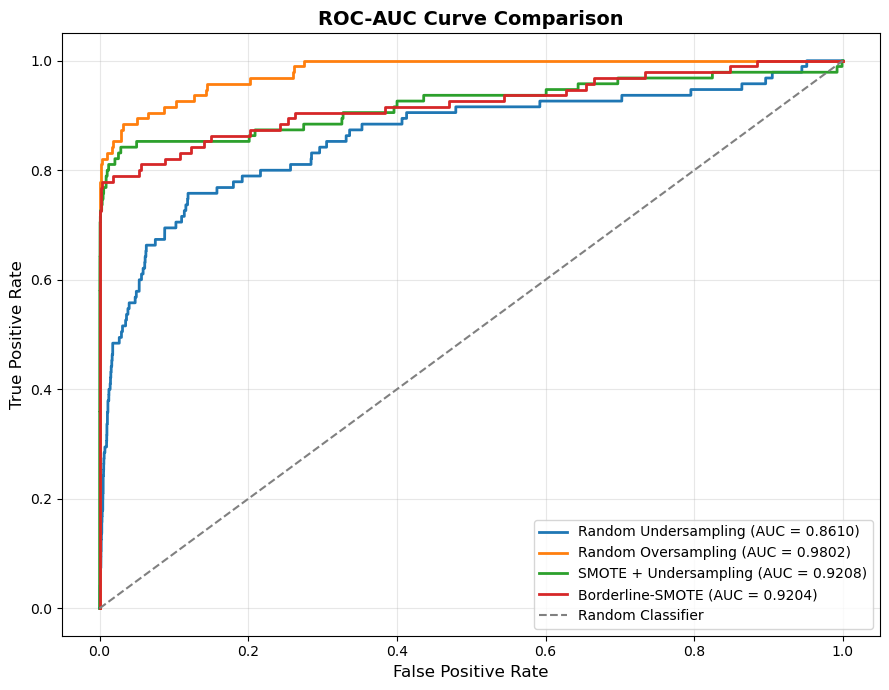

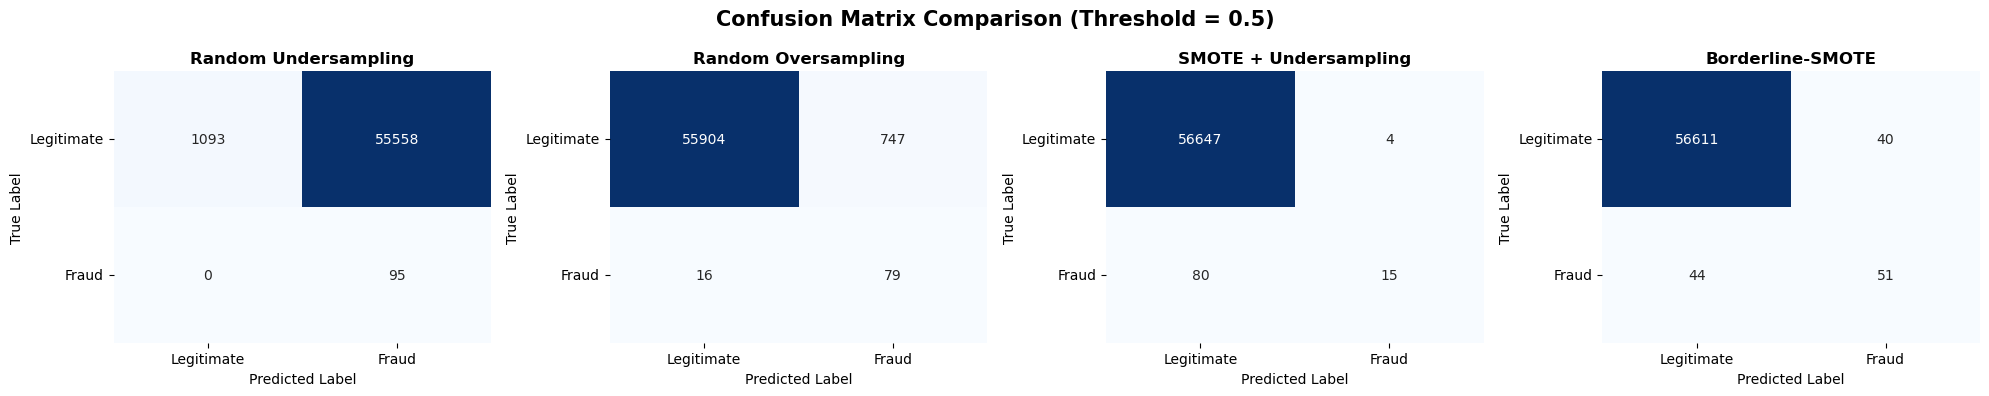

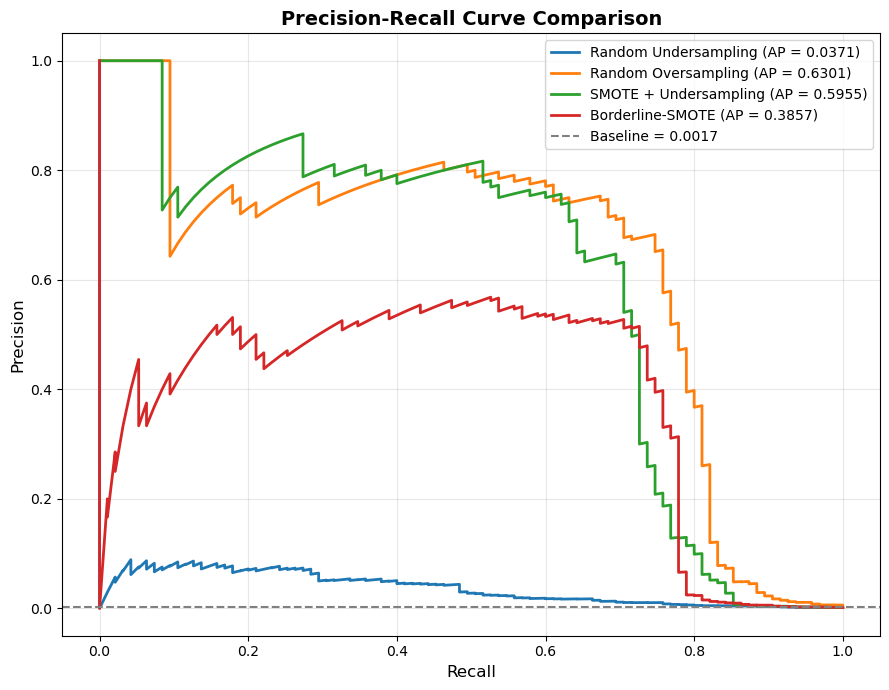

In [226]:
#Displaying the result
plot_keras_tuned_performance(
    model_data=models_kt_dl,
    threshold=0.5
)

In [230]:
#Define the DL models

#"Random Under Sampling": history_rand_us,
#"Random Over Sampling": history_rand_os,
#"SMOTE + Under Sampling": history_smote_us,
#"Borderline-SMOTE": history_bs_new #history_bs


models_dl = {

    "Random Undersampling": {
        "model": model_rand_us,
        "x_test": x_rand_under_test_scaled,
        "y_test": y_test
    },

    "Random Oversampling": {
        "model": model_rand_os,
        "x_test": x_test_rand_os,
        "y_test": y_test
    },

    "SMOTE + Undersampling": {
        "model": model_smote_us,
        "x_test": x_test_smote_us,
        "y_test": y_test
    },

    "Borderline-SMOTE": {
        "model": model_bs,
        "x_test": x_test_bs,
        "y_test": y_test
    }
}

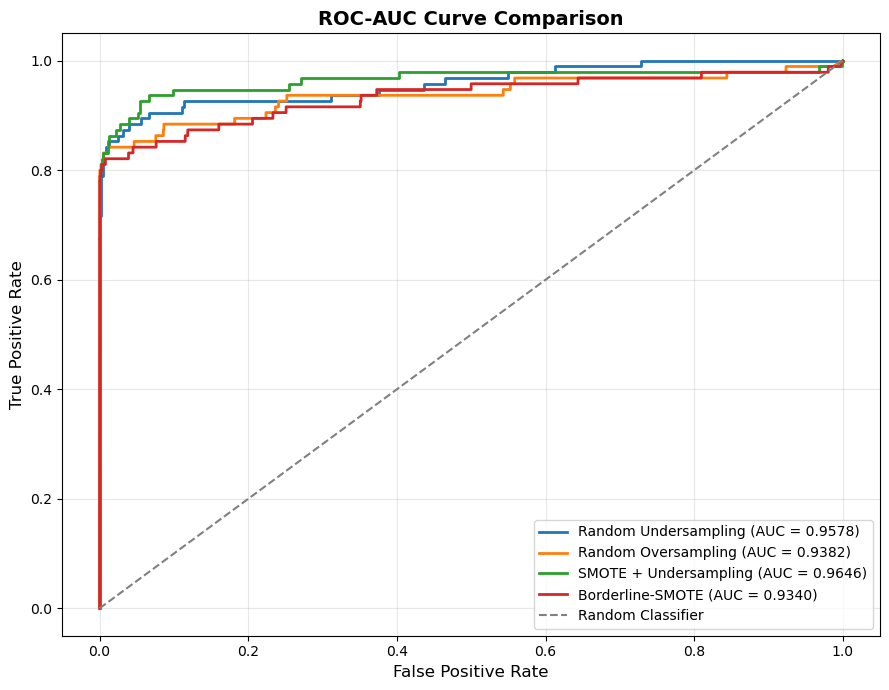

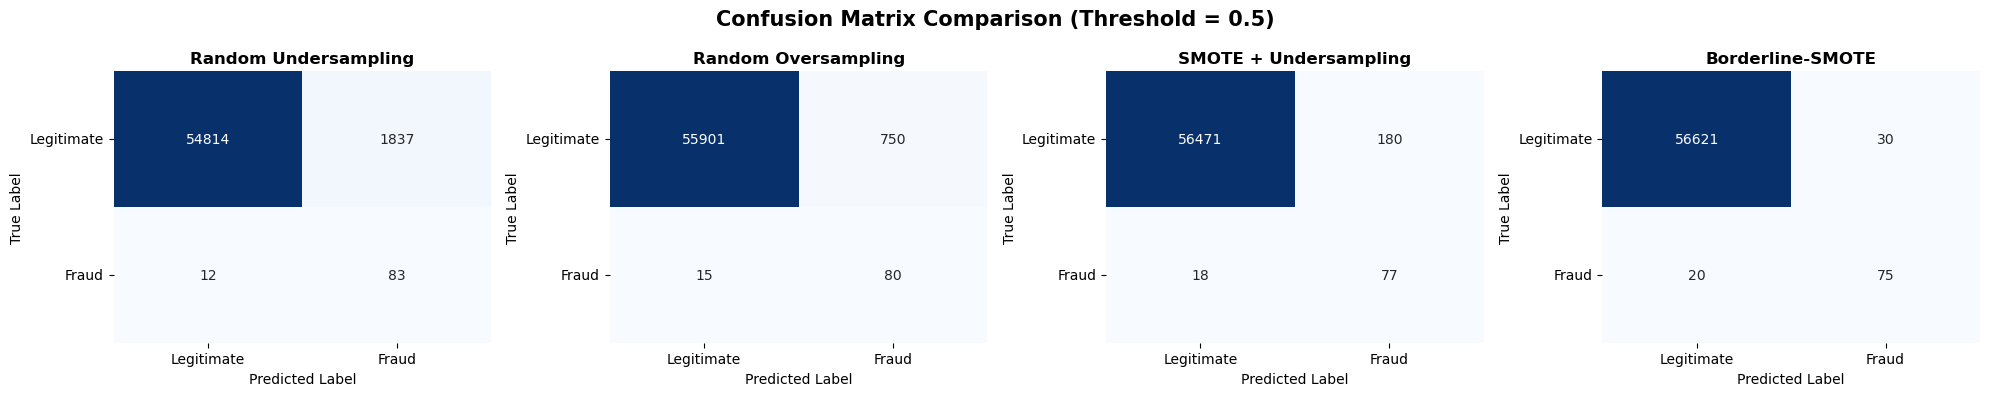

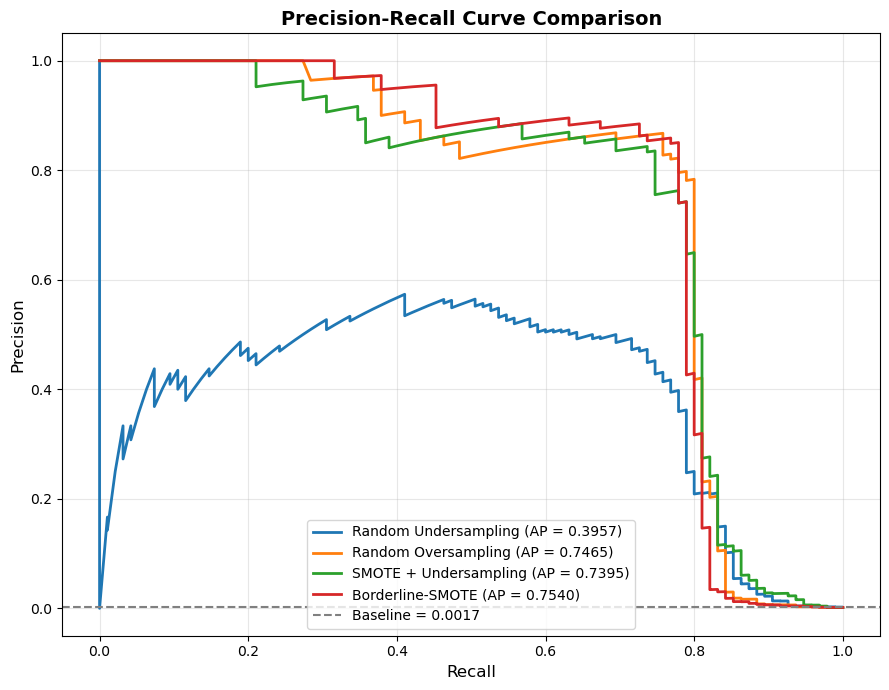

In [231]:
#Displaying the result
plot_keras_tuned_performance(
    model_data=models_dl,
    threshold=0.5
)

In [232]:
#Save the models
model_bs.save("dl_borderline_smote.keras")
model_bs_kt.save("dl_kt_borderline_smote.keras")

In [237]:
pickle.dump(pt_bs, open("powertransformer_bs_cc_fraud.pkl", "wb"))  #Power transformer
pickle.dump(scaler_bs, open("scaler_bs_cc_fraud.pkl", "wb")) #StandardMaxScaler

In [255]:
#Test

skewed_cols = [ 'V1',
                'V2',
                'V3',
                'V5',
                'V6',
                'V7',
                'V9',
                'V10',
                'V12',
                'V14',
                'V16',
                'V17',
                'V18',
                'V20',
                'V21',
                'V22',
                'V23',
                'V24',
                'V27',
                'V28',
                'Amount']

fraud_row = df[df["Class"] == 1].iloc[[2]]

X_fraud = fraud_row.drop(columns=["Class"])

X_fraud_transformed = X_fraud.copy()

X_fraud_transformed[skewed_cols] = pt_bs.transform(
    X_fraud_transformed[skewed_cols]
)

X_fraud_scaled = scaler_bs.transform(
    X_fraud_transformed
)

probability = model_bs.predict(
    X_fraud_scaled
)
predicted_class = (probability > 0.5).astype(int)[0][0]
#print("Actual class:", fraud_row["Class"].values[0])
print("Actual class:", probability)
print("Predicted probability:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Actual class: [[0.999638]]
Predicted probability: 1


In [246]:
import sys

print(sys.executable)

print(sys.version)

C:\Users\Dhrubajyoti Ghosh\anaconda3\python.exe
3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:09:58) [MSC v.1929 64 bit (AMD64)]


In [247]:
import keras

print("Keras version:", keras.__version__)

Keras version: 3.15.1


In [248]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [249]:
import sklearn
print(sklearn.__version__)

1.8.0


**Streamlit Code**
------------------

import streamlit as st
import joblib
import numpy as np
import pickle
import pandas as pd
import keras


st.markdown(
    """
    <style>
    .stApp {
        background-color: #90EE90;
        color: brown;   /* default text color */
    }

    h1 {
        color: #1f77b4;  /* blue title */
    }

    label {
        color: #1f77b4 !important;
        font-weight: 600;
    }
    div[data-testid="stRadio"] div[role="radiogroup"] label span p {
        color: brown !important;
        font-weight: 600;
    }
    
    </style>
    """,
    unsafe_allow_html=True
)


pt = pickle.load(open("powertransformer_bs_cc_fraud.pkl", "rb"))
scaler = pickle.load(open("scaler_bs_cc_fraud.pkl", "rb"))

model = keras.models.load_model("dl_borderline_smote.keras") #for keras == 3.15.0
#DL Model
#model = pickle.load(open("ml_borderline_smote_xgb_model.pkl", "rb"))
#ML Model

st.markdown(
    "<h1 style='text-align: center;'>Credit Card Fraud Detection</h1>",
    unsafe_allow_html=True
)

#st.title("Credit Card Fraud Detection")
st.image("CC_img.png", use_container_width=True)

st.write("This app Classifies whether a transaction is fraudulent or not based on the input features provided by the user. Please fill in the PCA details below to get the prediction.")

Time = st.number_input("Time", min_value=0.0, value=0.0, step=1.0, format="%.1f")
V1 = st.number_input("V1", min_value=-100.0, value=0.0, step=0.1, format="%.15f")
V2 = st.number_input("V2", min_value=-100.0, value=0.0, step=0.1, format="%.15f")
V3 = st.number_input("V3", min_value=-100.0, value=0.0, step=0.1, format="%.15f")
V4 = st.number_input("V4", min_value=-100.0, value=0.0, step=0.1, format="%.15f")
V5 = st.number_input("V5", min_value=-100.0, value=0.0, step=0.1, format="%.15f")
V6 = st.number_input("V6", min_value=-100.0, value=0.0, step=0.1, format="%.15f")
V7 = st.number_input("V7", min_value=-100.0, value=0.0, step=0.1, format="%.15f")
V8 = st.number_input("V8", min_value=-100.0, value=0.0, step=0.1, format="%.15f")
V9 = st.number_input("V9", min_value=-100.0, value=0.0, step=0.1, format="%.15f")
V10 = st.number_input("V10", min_value=-100.0, value=0.0, step=0.1, format="%.15f")
V11 = st.number_input("V11", min_value=-100.0, value=0.0, step=0.1, format="%.15f")
V12 = st.number_input("V12", min_value=-100.0, value=0.0, step=0.1, format="%.15f")
V13 = st.number_input("V13", min_value=-100.0, value=0.0, step=0.1, format="%.15f")
V14 = st.number_input("V14", min_value=-100.0, value=0.0, step=0.1, format="%.15f")
V15 = st.number_input("V15", min_value=-100.0, value=0.0, step=0.1, format="%.15f")
V16 = st.number_input("V16", min_value=-100.0, value=0.0, step=0.1, format="%.15f")
V17 = st.number_input("V17", min_value=-100.0, value=0.0, step=0.1, format="%.15f")
V18 = st.number_input("V18", min_value=-100.0, value=0.0, step=0.1, format="%.15f")
V19 = st.number_input("V19", min_value=-100.0, value=0.0, step=0.1, format="%.15f")
V20 = st.number_input("V20", min_value=-100.0, value=0.0, step=0.1, format="%.15f")
V21 = st.number_input("V21", min_value=-100.0, value=0.0, step=0.1, format="%.15f")
V22 = st.number_input("V22", min_value=-100.0, value=0.0, step=0.1, format="%.15f")
V23 = st.number_input("V23", min_value=-100.0, value=0.0, step=0.1, format="%.15f")
V24 = st.number_input("V24", min_value=-100.0, value=0.0, step=0.1, format="%.15f")
V25 = st.number_input("V25", min_value=-100.0, value=0.0, step=0.1, format="%.15f")
V26 = st.number_input("V26", min_value=-100.0, value=0.0, step=0.1, format="%.15f")
V27 = st.number_input("V27", min_value=-100.0, value=0.0, step=0.1, format="%.15f")
V28 = st.number_input("V28", min_value=-100.0, value=0.0, step=0.1, format="%.15f")
Amount = st.number_input("Amount", min_value=0.0, value=0.0, step=1.0, format="%.2f")


if st.button("Classify Transaction"):

    all_inputs = [
    Time, V1, V2, V3, V4, V5, V6, V7, V8, V9,
    V10, V11, V12, V13, V14, V15, V16, V17, V18,
    V19, V20, V21, V22, V23, V24, V25, V26, V27, V28,
    Amount
    ]   

    if all(value == 0 for value in all_inputs):

        st.markdown(
            """
            <div style="
                background-color:#fff3e0;
                padding:15px;
                border-radius:10px;
                border:2px solid #ff9800;
                color:#e65100;
                font-size:18px;
                font-weight:bold;
                text-align:center;
            ">
                ⚠️ Please enter valid Input
            </div>
            """,
            unsafe_allow_html=True
        )

    else:

        feature_names = [
            'Time',
            'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9',
            'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17',
            'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25',
            'V26', 'V27', 'V28',
            'Amount'
        ]

        #input_data = np.array([[Time, V1, V2, V3, V4, V5, V6, V7, V8, V9, V10, V11, V12, V13, V14,
        #                       V15, V16, V17, V18, V19, V20, V21, V22, V23, V24, V25,
        #                       V26, V27, V28, Amount]])

        input_data = pd.DataFrame(
            [[
                Time,
                V1, V2, V3, V4, V5, V6, V7, V8, V9, V10,
                V11, V12, V13, V14, V15, V16, V17, V18,
                V19, V20, V21, V22, V23, V24, V25, V26,
                V27, V28,
                Amount
            ]],
            columns=feature_names
        )

        skewed_cols = ['V1',
                        'V2',
                        'V3',
                        'V5',
                        'V6',
                        'V7',
                        'V9',
                        'V10',
                        'V12',
                        'V14',
                        'V16',
                        'V17',
                        'V18',
                        'V20',
                        'V21',
                        'V22',
                        'V23',
                        'V24',
                        'V27',
                        'V28',
                        'Amount']

        input_data[skewed_cols] = pt.transform(input_data[skewed_cols])
        
        input_data_scaled = scaler.transform(input_data)    
        
        prediction = model.predict(input_data_scaled)
        predicted_class = (prediction > 0.3).astype(int)[0][0]
        #DL Model
        #predicted_class = int(prediction[0])
        #ML Model

        #st.write(input_data_scaled)
        #st.write(prediction)

        if predicted_class == 1:
            Prediction_text = "The transaction is classified as Fraudulent."
        else:
            Prediction_text = "The transaction is classified as Non-Fraudulent."

        if Prediction_text == "The transaction is classified as Fraudulent.":
            bg_color = "#ffebee"      # Light red
            border_color = "#d32f2f"  # Red
            text_color = "#b71c1c"    # Dark red
        else:
            bg_color = "#e8f5e9"      # Light green
            border_color = "#388e3c"  # Green
            text_color = "#1b5e20"    # Dark green

        st.markdown(
            f"""
            <div style="
                background-color:{bg_color};
                padding:15px;
                border-radius:10px;
                border:2px solid {border_color};
                color:{text_color};
                font-size:18px;
                font-weight:bold;
                text-align:center;
            ">
                Predicted Machine Failure Possibility: {Prediction_text}
            </div>
            """,
            unsafe_allow_html=True
        )

        #            Fraud Probability: {prediction}
